In [ ]:
pd.set_option('display.', None)

In [1]:
palette1 = ['#fcaa82', '#fab968', '#57b0d6', '#7acab2', '#b4d39d', '#fbd887', '#f79f70', '#80bbb8', '#88a1b7', '#fa7f81']
palette2 = ["#ffadad","#ffd6a5","#fdffb6","#caffbf","#9bf6ff","#a0c4ff","#bdb2ff","#ffc6ff","#fffffc"]
palette5 = ['#d47707','#247496','#6c9d47','#e1090d', "#8007e9"]

In [2]:
WORKSPACE = "/Users/charvijain16/PhD/git_repos/UI_SYSBIO_Sol_Lib"
DATASET = "my_dataset"
TYPE = "direct"

images_folder = f"{WORKSPACE}/all_images/{DATASET}/{TYPE}"
MODEL_OUTPUTS_DIR =  f"{WORKSPACE}/all_outputs/{DATASET}/{TYPE}"
EVAL_OUTPUT_DIR= f"{WORKSPACE}/src/evaluation/eval_outputs/{DATASET}/{TYPE}/report_n_references/files"


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')
import nltk

In [4]:
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/charvijain16/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [5]:
import pandas as pd
import json


def load_GT(file_path: str) -> pd.DataFrame:
    # Read the raw text
    with open(file_path, "r") as f:
        content = f.read()

    # Manually split into JSON objects
    # (Assuming objects are just stacked without commas/newlines)
    objects = content.strip().split("}\n{")
    objects = [o + "}" if not o.endswith("}") else o for o in objects]  # Fix ending }
    objects = [
        "{" + o if not o.startswith("{") else o for o in objects
    ]  # Fix starting {

    # Parse each JSON object
    data = [json.loads(obj) for obj in objects]

    # Convert to DataFrame
    gt = pd.DataFrame(data)
    return gt

In [6]:
import pandas as pd
import pickle, os

def load_results_from_pickle(pkl_path):
    """Load results dataframe from pickle file if it exists"""
    if os.path.exists(pkl_path):
        try:
            with open(pkl_path, "rb") as in_f:
                return pd.read_pickle(in_f)
        except (pickle.PickleError, EOFError):
            print(f"Could not load existing results from {pkl_path}, starting fresh")
            return None
    return None


In [7]:
gpt_results = load_results_from_pickle(f"{MODEL_OUTPUTS_DIR}/gpt-4.1-2025-04-14_results.pkl")
llama_results = load_results_from_pickle(f"{MODEL_OUTPUTS_DIR}/meta-llama_Llama-3.3-70B-Instruct_results.pkl")
claude_results = load_results_from_pickle(f"{MODEL_OUTPUTS_DIR}/claude-3-5-sonnet-20240620_results.pkl")
gemini_results = load_results_from_pickle(f"{MODEL_OUTPUTS_DIR}/gemini-2.5-pro_results.pkl")

In [13]:
gemini_results['question'][8]

'Why is Ran GTPase activity essential for chromatin-induced cortical actin and myosin II organization in mouse oocytes?'

In [12]:
gemini_results['wtp_references'][8]

'\n[1]. Ran, RAN, member RAS oncogene family, GeneID:19384.\n[2]. Rangap1, RAN GTPase activating protein 1, GeneID:19387.\n[3]. Rcc1, regulator of chromosome condensation 1, GeneID:100088.\n[4]. RAN_MOUSE, ProteinID:P62827.\n[5]. The Ran GTPase mediates chromatin signaling to control cortical polarity during polar body extrusion in mouse oocytes., ID:17276346.\n\n'

In [9]:
gemini_results['wtp_answer'][8]

'### **The Essential Role of Ran GTPase Activity in Chromatin-Induced Cytoskeletal Organization in Mouse Oocytes**\n\n**Introduction**\n\nAsymmetric cell division is a fundamental process in developmental biology, enabling the generation of daughter cells with distinct sizes and fates. In female mammals, meiosis is characterized by highly asymmetric divisions that produce a large, viable oocyte and small, non-viable polar bodies. This asymmetry is crucial for conserving the maternal cytoplasm and nutrients for the future embryo. In mouse oocytes, the positioning of the meiotic spindle, which is dictated by the chromatin, serves as the primary spatial cue that breaks the symmetry of the cell cortex. This signal from the chromatin leads to the localized organization of cortical actin and myosin II, driving the formation and extrusion of the polar body. A key mediator in translating this chromatin-based positional signal to the cell cortex is the small GTPase, Ran. This report details why

In [26]:
gemini_results['wtnp_thought_process'][8]

[{'Thought': 'Thought: I need to investigate the role of Ran GTPase activity in the organization of cortical actin and myosin II in mouse oocytes, specifically in response to chromatin. I will start by searching for general information about Ran GTPase in mouse oocytes and its functions. I will begin with a broad search on PubMed to get an overview of the existing literature.',
  'Relevance': '-',
  'Action': 'Retrieve_PubMed',
  'ActionInput': {'search_string': 'Ran GTPase mouse oocyte chromatin actin myosin II'},
  'Observation': ('[{"id": "17276346", "pmcid": null, "Title": "The Ran GTPase mediates chromatin signaling to control cortical polarity during polar body extrusion in mouse oocytes.", "Abstract": "The molecular basis for asymmetric meiotic divisions in mammalian oocytes that give rise to mature eggs and polar bodies remains poorly understood. Previous studies demonstrated that the asymmetrically positioned meiotic chromosomes provide the cue for cortical polarity in mouse o

In [45]:
gpt_results['question'][8]

'Why is Ran GTPase activity essential for chromatin-induced cortical actin and myosin II organization in mouse oocytes?'

In [47]:
gpt_results['wtnp_thought_process'][8]

[{'Thought': 'Thought: To understand the question, I should first look for fundamental information about Ran GTPase in mouse oocytes, including its function and cellular role.',
  'Relevance': '-',
  'Action': 'Retrieve_Gene',
  'ActionInput': {'search_string': 'Ran GTPase AND Mus musculus'},
  'Observation': ('[{"id": "19384", "gene_name": "Ran", "description": "RAN, member RAS oncogene family", "organism": "Mus musculus", "summary": "Predicted to enable several functions, including G protein activity; dynein intermediate chain binding activity; and guanyl ribonucleotide binding activity. Predicted to contribute to pre-miRNA binding activity. Acts upstream of or within actin cytoskeleton organization; protein import into nucleus; and protein-containing complex localization. Located in cytoplasm and nuclear envelope. Is expressed in several structures, including branchial arch; central nervous system; extraembryonic component; hemolymphoid system gland; and sensory organ. Human ortholo

In [29]:
gpt_results.columns

Index(['id', 'Name', 'category', 'question', 'original_TP',
       'wtp_thought_process', 'wtp_answer', 'wtp_references',
       'wtp_referenece_ids', 'wtp_completion_tokens', 'wtp_total_tokens',
       'total_intermediate_steps', 'unique_tool_count', 'unique_tools_used',
       'all_tools_list', 'original_TP_completion_tokens',
       'original_TP_total_tokens', 'formatted_TP_tokens', 'clean_TP_tokens',
       'drop_tokens_after_preprocessing', 'wtnp_thought_process',
       'wtnp_answer', 'wtnp_references', 'wtnp_referenece_ids',
       'wtnp_completion_tokens', 'wtnp_total_tokens', 'wot_answer',
       'wot_completion_tokens', 'wot_total_tokens', 'error'],
      dtype='object')

In [ ]:
gpt_results['wtnp_thought_process'][14]

In [40]:
gpt_results['wtnp_thought_process'][14]

[{'Thought': 'Thought: To address the functional roles of eosinophil peroxidase (EPX) and myeloperoxidase (MPO) in osteoclast regulation in mice, I will start by retrieving information about their encoding genes in mice from NCBI Genes to establish their official symbols, aliases, and gene products.',
  'Relevance': '-',
  'Action': 'Retrieve_Gene',
  'ActionInput': {'search_string': 'eosinophil peroxidase OR myeloperoxidase AND Mus musculus'},
  'Observation': ('[{"id": "13861", "gene_name": "Epx", "description": "eosinophil peroxidase", "organism": "Mus musculus", "summary": "This gene encodes a member of the peroxidase superfamily of enzymes that is produced by eosinophils and plays a critical role in eliminating tissue-invasive parasites. The encoded preproprotein undergoes proteolytic processing to generate a heterodimeric enzyme that forms a predominant component of the intracellular granules of eosinophils. Mice lacking the encoded protein exhibit resistance to ulcerative coliti

In [16]:
gpt_results['question'][44]

'How do interactions between osteoclast precursors, RANKL signaling, and inflammatory cytokines refine our understanding of bone loss in RA in mice'

In [19]:
gpt_results['wtp_answer'][44]

'## Introduction\n\nRheumatoid arthritis (RA) is a chronic inflammatory disease characterized by persistent joint inflammation and progressive bone erosion. In mouse models, the pathophysiology of bone loss is driven by increased osteoclast activity, which results from complex crosstalk between osteoclast precursors, cellular signaling via receptor activator of nuclear factor κB ligand (RANKL), and the local proinflammatory cytokine milieu. This report synthesizes current molecular, cellular, and experimental insights to explain how these interactions refine our mechanistic understanding of bone destruction in murine RA.\n\n## RANKL, Osteoclast Precursors, and Osteoclastogenesis\n\nOsteoclast precursors are monocyte/macrophage-lineage cells that differentiate into multinuclear osteoclasts, which mediate bone resorption. The central driver of osteoclastogenesis is RANKL (encoded by Tnfsf11), which binds to its receptor RANK (encoded by Tnfrsf11a) on osteoclast precursor cells, initiatin

In [18]:
gpt_results['wtnp_answer'][44]

'### Introduction\n\nRheumatoid arthritis (RA) is a chronic autoimmune disease characterized by synovial inflammation and progressive bone destruction, driven largely by imbalance in bone remodeling. The interactions between osteoclast precursors, RANKL (Receptor Activator of Nuclear Factor κB Ligand) signaling, and inflammatory cytokines have emerged as central mechanisms underlying this bone loss, especially as demonstrated in mouse models of RA. Here, we synthesize the experimental, genetic, and molecular evidence that refines our mechanistic understanding of bone pathology in RA as it relates to osteoimmunology.\n\n---\n\n### RANKL Signaling and Osteoclastogenesis\n\nAt the heart of bone resorption in RA is the RANKL-RANK signaling axis. RANKL, encoded by Tnfsf11, is a key cytokine that binds to its receptor RANK (Tnfrsf11a) on osteoclast precursors, triggering their differentiation into mature, bone-resorbing osteoclasts. This signaling cascade induces prolonged calcium oscillatio

In [17]:
gpt_results['wot_answer'][44]

'**Comprehensive Report: Interactions Between Osteoclast Precursors, RANKL Signaling, and Inflammatory Cytokines in Bone Loss in Rheumatoid Arthritis (RA) Mouse Models**\n\n---\n\n### **Introduction**\n\nRheumatoid arthritis (RA) is characterized by chronic joint inflammation and progressive bone erosion. Central to this process are osteoclasts—bone-resorbing cells—derived from precursors in the monocyte/macrophage lineage. Three key players underlie the pathological bone loss in RA: osteoclast precursors, receptor activator of nuclear factor kappa-Β ligand (RANKL) signaling, and inflammatory cytokines. Mouse models of RA, such as collagen-induced arthritis (CIA) and the K/BxN serum-transfer arthritis, have been instrumental in unraveling their interplay. This report synthesizes current understanding of how these factors interact to potentiate bone loss in RA.\n\n---\n\n### **1. Osteoclast Precursors in RA**\n\n- **Origin & Recruitment**: Osteoclasts arise from hematopoietic progenitor

In [10]:
gpt_non_na_indices = gpt_results[gpt_results['error'].notna()].index
print(gpt_non_na_indices, len(gpt_non_na_indices))

llama_non_na_indices = llama_results[llama_results['error'].notna()].index
print(llama_non_na_indices, len(llama_non_na_indices))

claude_non_na_indices = claude_results[claude_results['error'].notna()].index
print(claude_non_na_indices, len(claude_non_na_indices))

gemini_non_na_indices = gemini_results[gemini_results['error'].notna()].index
print(gemini_non_na_indices, len(gemini_non_na_indices))

total_common_indices =  list(gpt_non_na_indices) + list(llama_non_na_indices) + list(claude_non_na_indices) + list(gemini_non_na_indices)

total_common_indices = set(total_common_indices)
total_common_indices, len(total_common_indices)

Index([], dtype='int64') 0
Index([], dtype='int64') 0
Index([], dtype='int64') 0
Index([], dtype='int64') 0


(set(), 0)

In [11]:
gpt_results.columns

Index(['id', 'Name', 'category', 'question', 'original_TP',
       'wtp_thought_process', 'wtp_answer', 'wtp_references',
       'wtp_referenece_ids', 'wtp_completion_tokens', 'wtp_total_tokens',
       'total_intermediate_steps', 'unique_tool_count', 'unique_tools_used',
       'all_tools_list', 'original_TP_completion_tokens',
       'original_TP_total_tokens', 'formatted_TP_tokens', 'clean_TP_tokens',
       'drop_tokens_after_preprocessing', 'wtnp_thought_process',
       'wtnp_answer', 'wtnp_references', 'wtnp_referenece_ids',
       'wtnp_completion_tokens', 'wtnp_total_tokens', 'wot_answer',
       'wot_completion_tokens', 'wot_total_tokens', 'error'],
      dtype='object')

In [4]:
final_df = load_GT("/Users/charvijain16/PhD/git_repos/UI_SYSBIO_Sol_Lib/all_datasets/my_dataset/gt_entries_39_sept19.jsonl")


In [25]:
final_df.columns

Index(['id', 'Name', 'category', 'question', 'thoughtprocess', 'final_answer',
       'must_have_statements', 'nice_have_statements',
       'parsed_thoughtprocess'],
      dtype='object')

In [26]:
final_df['final_answer'][26]

'Rheumatoid arthritis (RA) is a chronic autoimmune disorder that results in systemic and local bone loss, primarily mediated by the pathological activation of osteoclasts. Understanding the interactions between osteoclast precursors, RANKL signaling, and inflammatory cytokines provides insights into the mechanisms of bone degradation in RA, particularly in murine models.\n\nOsteoclasts are the primary effector cells responsible for bone resorption and are derived from the monocyte/macrophage lineage. Osteoclastogenesis is heavily dependent on the RANKL (Receptor Activator of Nuclear Factor Kappa-B Ligand) signaling pathway, where RANKL binds to its receptor RANK on osteoclast precursors, promoting their differentiation into mature osteoclasts [5]. This process is tightly regulated by several transcription factors, including NFATc1, and is influenced by various signaling pathways like NF-kappa B, MAPK, and JNK [7][8].\n\nThe role of RANKL in RA is underscored by its expression in T cell

In [13]:
final_df.columns

Index(['id', 'Name', 'category', 'question', 'thoughtprocess', 'final_answer',
       'must_have_statements', 'nice_have_statements',
       'parsed_thoughtprocess'],
      dtype='object')

In [14]:
final_df["total_intermediate_steps"] = None
final_df["all_tools_list"] = None
for index, row in final_df.iterrows():
    tp = row["parsed_thoughtprocess"]
    final_df["total_intermediate_steps"][index] = len(tp) - 1
    all_tools_list = []
    for trace in row["parsed_thoughtprocess"]:
        all_tools_list.append(trace.get("action", ""))
    cleaned_list = [x for x in all_tools_list if x is not None]
    final_df["all_tools_list"][index] = cleaned_list
        
final_df["model_type"]="Human"  

In [15]:
gpt_results_filtered = gpt_results[gpt_results['id'].isin(final_df['id'])]
llama_results_filtered = llama_results[llama_results['id'].isin(final_df['id'])]
claude_results_filtered = claude_results[claude_results['id'].isin(final_df['id'])]
gemini_results_filtered = gemini_results[gemini_results['id'].isin(final_df['id'])]


In [16]:
gpt_results_filtered["model_type"] = "GPT-4.1"
llama_results_filtered["model_type"] = "LLAMA-3.3-70B"
claude_results_filtered["model_type"] = "Claude-3.5-Sonnet"
gemini_results_filtered["model_type"] = "Gemini-2.5-Pro"


In [17]:
# gpt_results_filtered["all_tools_list"] = None
# for index, row in gpt_results_filtered.iterrows():
#     tp = row["wtnp_thought_process"]
#     all_tools_list=[]
#     if tp != None:
#         for trace in tp:
#             all_tools_list.append(trace.get("Action", ""))
#     cleaned_list = [x for x in all_tools_list if x is not None]
#     gpt_results_filtered["all_tools_list"][index] = cleaned_list
    

# llama_results_filtered["all_tools_list"] = None
# for index, row in llama_results_filtered.iterrows():
#     tp = row["wtnp_thought_process"]
#     all_tools_list=[]
#     if tp != None:
#         for trace in tp:
#             all_tools_list.append(trace.get("Action", ""))
#     cleaned_list = [x for x in all_tools_list if x is not None]
#     llama_results_filtered["all_tools_list"][index] = cleaned_list


In [18]:
combined_df = pd.concat([gpt_results_filtered, llama_results_filtered, claude_results_filtered, gemini_results_filtered, final_df], ignore_index=True)

In [19]:
combined_df.shape

(195, 36)

# REFERENCES

In [20]:
# import re

# entry_id = 3
# # for i, row in final_df.iterrows():

# answer=final_df.loc[final_df["id"] == entry_id, "final_answer"].values[0]
# references_gt=answer.split("References:")[1]
# ids = re.findall(r'(?:KEGG_PATHWAY_ID|ID|ProteinID|GeneID|MUTATION_ID):[^\s.,]+', references_gt)
# gt_refs = set(ids)
# clean_gt_refs = [item.split(":")[1] for item in gt_refs]

# model1_refs = llama_results_filtered.loc[llama_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
# model2_refs= gpt_results_filtered.loc[llama_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
# model3_refs= gemini_results_filtered.loc[llama_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
# model4_refs= claude_results_filtered.loc[llama_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []


# # row['wtnp_referenece_ids']


In [21]:
list(final_df["id"])

[1,
 3,
 4,
 6,
 7,
 8,
 9,
 11,
 12,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 23,
 24,
 25,
 33,
 34,
 35,
 36,
 42,
 44,
 45,
 47,
 48,
 50,
 52,
 53,
 54,
 56,
 57,
 58,
 59,
 60,
 61]

In [22]:
import re
competitors_output_dict = {}
competitors = ["GPT", "LLAMA", "Claude", "Gemini", "Human"]
for competitor_name in competitors:
    for entry_id in list(final_df["id"]):
        if competitor_name  == 'LLAMA':
            competitors_output_dict[entry_id] = {} if entry_id not in competitors_output_dict else competitors_output_dict[entry_id]
            competitors_output_dict[entry_id][competitor_name] = llama_results_filtered.loc[llama_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
        elif competitor_name == 'GPT':
            competitors_output_dict[entry_id] = {} if entry_id not in competitors_output_dict else competitors_output_dict[entry_id]
            competitors_output_dict[entry_id][competitor_name] = gpt_results_filtered.loc[gpt_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
        elif competitor_name == 'Claude':
            competitors_output_dict[entry_id] = {} if entry_id not in competitors_output_dict else competitors_output_dict[entry_id]
            competitors_output_dict[entry_id][competitor_name] = claude_results_filtered.loc[claude_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
        elif competitor_name == 'Gemini':
            competitors_output_dict[entry_id] = {} if entry_id not in competitors_output_dict else competitors_output_dict[entry_id]
            competitors_output_dict[entry_id][competitor_name] = gemini_results_filtered.loc[gemini_results_filtered["id"] == entry_id, "wtp_referenece_ids"].values[0] or []
        elif competitor_name == 'Human':
            competitors_output_dict[entry_id] = {} if entry_id not in competitors_output_dict else competitors_output_dict[entry_id]
            answer=final_df.loc[final_df["id"] == entry_id, "final_answer"].values[0]
            references_gt=answer.split("References:")[1]
            ids = re.findall(r'(?:KEGG_PATHWAY_ID|ID|ProteinID|GeneID|MUTATION_ID):[^\s.,]+', references_gt)
            gt_refs = set(ids)    
            competitors_output_dict[entry_id][competitor_name] = [item.split(":")[1] for item in gt_refs]
        else:
            print('Competitor not found')

In [23]:
competitors_output_dict

{1: {'GPT': ['35771433',
   '34080153',
   '16945018',
   '33861238',
   '21654619',
   '32183960',
   '33139937',
   '34757720',
   '2021638'],
  'LLAMA': ['34757720', '35771433', '33139937'],
  'Claude': ['16934355',
   '16945018',
   '19493011',
   '21254392',
   '24552450',
   '24905799'],
  'Gemini': ['21254392',
   '14516073',
   '22495585',
   '7791010',
   '2949017',
   '34264465',
   '24637356',
   '22433785'],
  'Human': ['37936577']},
 3: {'GPT': ['map05323', '20193003', '20510236'],
  'LLAMA': ['7422',
   '7040',
   '3569',
   '7124',
   '348',
   '3553',
   '1116',
   '7157',
   '7099',
   '5320',
   'Q13114',
   'Q5STB3',
   'Q687X5',
   'Q62293',
   'P28062',
   'O54693',
   'Q3T9E4',
   'P61125',
   'P32970',
   'Q8HZD9'],
  'Claude': ['1116',
   '4318',
   '3553',
   '7124',
   '5320',
   '3569',
   'Q9UBM4',
   '26572612',
   '2682979',
   '28456616',
   '9266128'],
  'Gemini': ['1009', 'P55287', '31956018', '38783357', '23147896'],
  'Human': ['20510236', '20193003',

### Exhaustiveness

In [24]:
# def exhaustiveness_of_A(query_id, toolA, toolB, competitors_output_dict):
#     toolA_results = competitors_output_dict[query_id][toolA]
#     toolB_results = competitors_output_dict[query_id][toolB]

#     alpha = len(set(toolA_results).intersection(set(toolB_results))) / len(set(toolB_results))
#     return round(alpha, 2)

def exhaustiveness_of_A(query_id, toolA, toolB, competitors_output_dict):
    toolA_results = competitors_output_dict.get(query_id, {}).get(toolA, [])
    toolB_results = competitors_output_dict.get(query_id, {}).get(toolB, [])

    # If toolB has no results, exhaustiveness is undefined → return 0.0
    if not toolB_results:
        return 0.0

    # If toolA has no results, intersection will always be empty → return 0.0
    if not toolA_results:
        return 0.0

    alpha = len(set(toolA_results).intersection(set(toolB_results))) / len(set(toolB_results))
    return round(alpha, 2)


### Recall

In [25]:
def recall_of_A(query_id, toolA, competitors_output_dict):
    toolA_results = competitors_output_dict[query_id][toolA]
    all_results = list(competitors_output_dict[query_id].values())
    flattened_list = [item for sublist in all_results for item in sublist]
    
    recall_score = len(set(toolA_results))/len(set(flattened_list))
    return recall_score

In [26]:
def create_Empty_df(competitors):
    df = pd.DataFrame(columns=competitors)
    df[competitors[0]] =  list(range(len(competitors)))
    df.index = competitors
    df = df.astype(float)
    return df

In [27]:
all_query_dfs = {}
for query_id, outputs in competitors_output_dict.items():
    if not all(key in outputs for key in competitors):
        continue
    else:
        df_name = "df_" + str(query_id)
        df = create_Empty_df(competitors)
        for toolA, row in df.iterrows():
            for toolB in df.columns:
                if toolA != toolB:
                    df.loc[toolA, toolB] = exhaustiveness_of_A(query_id, toolA, toolB, competitors_output_dict)
                else:
                    df.loc[toolA, toolB] = 0.00
        all_query_dfs[f"df_{query_id}"] = df

In [28]:
refereces_scores_df = []
for key, df in all_query_dfs.items():
    refereces_scores_df.append(df)

final=sum(refereces_scores_df)/len(all_query_dfs)

In [29]:
final.to_csv(os.path.join(images_folder, "reference_exhaustiveness.csv"))

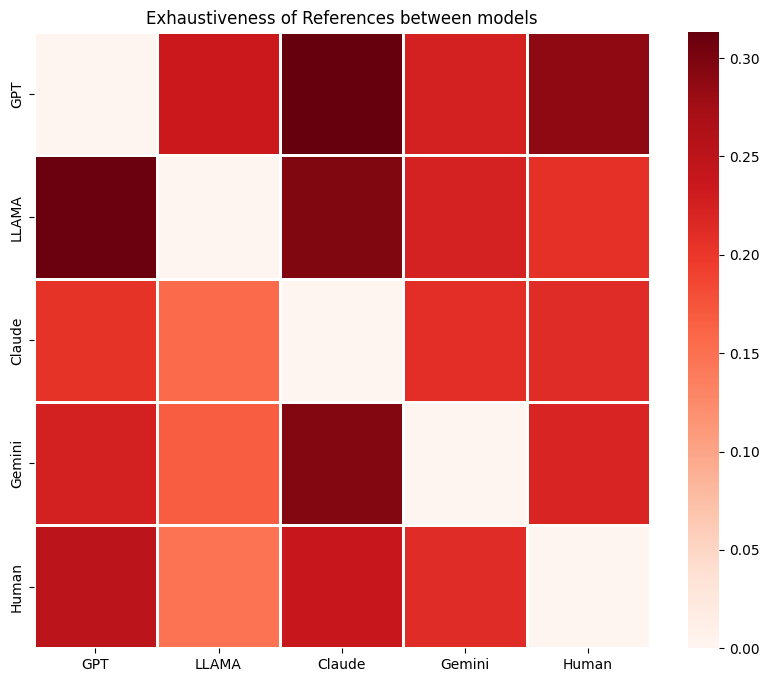

In [30]:
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

palette4 = ["#ebfffb","#d8f4ed","#c4e8de","#85f2cc","#45fcba","#1ce3a4","#0f986d","#014c35","#001e15"]
# Create a continuous colormap from your colors
custom_cmap = LinearSegmentedColormap.from_list("custom_heatmap", palette4)

# Plot the heat map
plt.figure(figsize=(10, 8))
sns.heatmap(final, annot=False, cmap="Reds", cbar=True, square=True,
            linewidths=0.8)

# Add title and labels
plt.title(f"Exhaustiveness of References between models")
filename = "References_Exhaustiveness"
os.makedirs(images_folder, exist_ok=True)
plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")
plt.show()




In [31]:
recall_dataframe = pd.DataFrame(columns=competitors)
recall_dataframe[competitors[0]] =  list([0]*(len(competitors_output_dict)))
recall_dataframe.index = list(competitors_output_dict.keys())
recall_dataframe = recall_dataframe.astype(float)

for query_id, outputs in competitors_output_dict.items():
    if not all(key in outputs for key in competitors):
        continue
    else:
        for toolA, values in outputs.items():
            recall_dataframe.loc[query_id, toolA] = recall_of_A(query_id, toolA, competitors_output_dict)

mean_row = recall_dataframe.sum() / len(recall_dataframe)
recall_dataframe.loc['Recall Scores'] = mean_row
recall_dataframe

,GPT,LLAMA,Claude,Gemini,Human
1,0.409091,0.136364,0.272727,0.363636,0.045455
3,0.083333,0.555556,0.305556,0.138889,0.138889
4,0.136364,0.545455,0.204545,0.113636,0.159091
6,0.437500,0.125000,0.437500,0.437500,0.125000
7,0.392857,0.500000,0.053571,0.232143,0.071429
8,0.666667,0.666667,0.666667,0.500000,0.833333
9,0.400000,0.400000,0.200000,0.500000,0.600000
11,0.122449,0.591837,0.081633,0.204082,0.285714
12,0.279070,0.441860,0.162791,0.186047,0.302326
14,0.400000,0.800000,0.300000,0.500000,0.300000


In [32]:
recall_dataframe.to_csv(os.path.join(images_folder, "recall_dataframe.csv"))

In [33]:
recall_dataframe.tail(1)

,GPT,LLAMA,Claude,Gemini,Human
Recall Scores,0.276825,0.444734,0.202155,0.254824,0.258186


In [34]:
last_row = recall_dataframe.iloc[-1]
rounded_last_row = last_row.round(3)
rounded_last_row

GPT       0.277
LLAMA     0.445
Claude    0.202
Gemini    0.255
Human     0.258
Name: Recall Scores, dtype: float64

In [35]:
rounded_last_row.T.to_csv(f"{images_folder}/recall_score_references.csv")

# Histograms

In [36]:
max(combined_df['total_intermediate_steps'])

15

Average total intermediate steps per model:
model_type
Claude-3.5-Sonnet     8.820513
GPT-4.1              10.153846
Gemini-2.5-Pro       10.025641
Human                 7.205128
LLAMA-3.3-70B         7.589744
Name: total_intermediate_steps, dtype: object


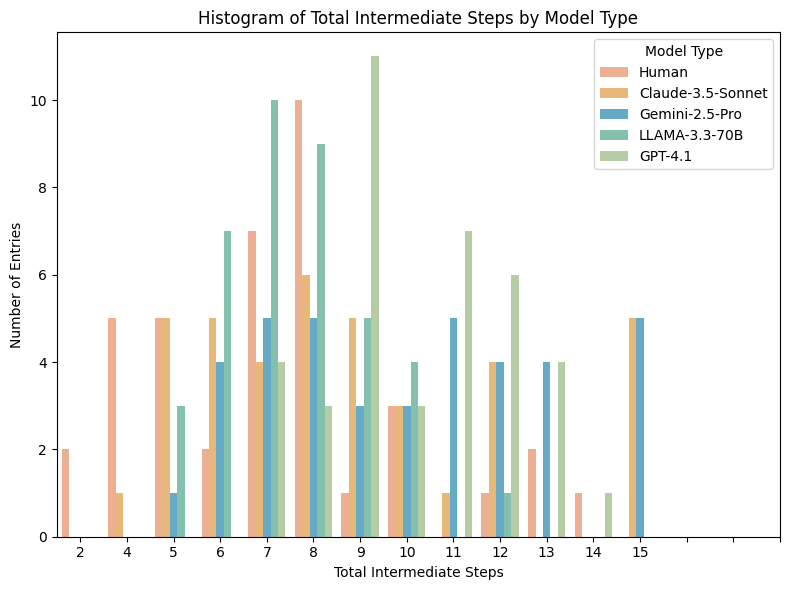

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Let's say 'gpt_results' has columns: 'total_intermediate_steps' and 'model_type'
# Filter only steps from 1 to 20
filtered = combined_df[combined_df['total_intermediate_steps'].between(1, 17)]

# Count occurrences of each step per model
step_counts_df = (
    filtered
    .groupby(['total_intermediate_steps', 'model_type'])
    .size()
    .reset_index(name='count')
)

# Plot multiple distributions using 'hue'
plt.figure(figsize=(8, 6))
sns.barplot(
    data=step_counts_df,
    x='total_intermediate_steps',
    y='count',
    hue='model_type',
    palette=palette1
)

# Add labels and title
plt.xlabel('Total Intermediate Steps')
plt.ylabel('Number of Entries')
plt.title('Histogram of Total Intermediate Steps by Model Type')
plt.xticks(range(0, 16))  # Show x-ticks from 0 to 20
plt.legend(title='Model Type')
plt.tight_layout()


# Optional: print average per group
avg_per_model = combined_df.groupby('model_type')['total_intermediate_steps'].mean()
print("Average total intermediate steps per model:")
filename = "Histogram_of_total_intermediate_steps"
os.makedirs(images_folder, exist_ok=True)
plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")
print(avg_per_model)

plt.show()


# Stylometric Analysis

In [38]:
# Thought choices = [1,2,3]
# Thought choices = [-3,-2,-1]
# Thought choices = [1, random, random, -1]
# Thought choices= [random, random, random, random]

In [39]:
import random

# Flexible index selector
def select_indices_from_list(lst, index_pattern, selected_items, entry_id, total_thoughts_available):
    length = len(lst)
    used_indices = set()

    # How many 'random' slots are requested
    num_randoms_requested = index_pattern.count('random')

    # Collect valid fixed indices from the pattern (normalize negatives)
    fixed_indices_set = set()
    for i in index_pattern:
        if i != 'random' and isinstance(i, int):
            actual = i if i >= 0 else length + i
            if 0 <= actual < length:
                fixed_indices_set.add(actual)

    # Available indices for random picks exclude fixed ones (so we don't collide later)
    available_indices = list(set(range(length)) - fixed_indices_set)

    # We can only sample as many randoms as are available
    num_randoms = min(num_randoms_requested, len(available_indices))
    random_choices = random.sample(available_indices, num_randoms)
    random_iter = iter(random_choices)

    for idx in index_pattern:
        if idx == 'random':
            # Try to get a random index; if exhausted, skip
            try:
                actual_idx = next(random_iter)
            except StopIteration:
                continue
        else:
            # Normalize negative indices and validate
            actual_idx = idx if idx >= 0 else length + idx
            if actual_idx < 0 or actual_idx >= length:
                continue  # Skip invalid indices

        # Avoid duplicate selections
        if actual_idx not in used_indices:
            new_row = {'entry_id':entry_id, 'thought': lst[actual_idx]['thought'], 'trace_index': actual_idx, 'total_thoughts_available':total_thoughts_available}
            selected_items.loc[len(selected_items)] = new_row
            used_indices.add(actual_idx)

    return selected_items


In [40]:
#index_pattern=[0, -1]
index_pattern = [0, 'random', 'random']

In [41]:
human_thoughts = pd.DataFrame()
human_thoughts["entry_id"] = ""
human_thoughts["thought"] = ""
human_thoughts["trace_index"] = ""
human_thoughts["total_thoughts_available"] = ""

for index, row in final_df.iterrows():
    tp = row["parsed_thoughtprocess"]
    total_thoughts_available=len(tp)
    assert(total_thoughts_available == row["total_intermediate_steps"], True)
    human_thoughts = select_indices_from_list(tp, index_pattern, human_thoughts, row["id"], total_thoughts_available-1)
    print(total_thoughts_available, row["total_intermediate_steps"])

human_thoughts["model_type"] = "Human"
human_thoughts = human_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")


5 4
6 5
9 8
8 7
8 7
9 8
9 8
9 8
6 5
6 5
9 8
13 12
8 7
3 2
11 10
9 8
3 2
8 7
14 13
11 10
6 5
8 7
8 7
9 8
14 13
9 8
11 10
5 4
6 5
5 4
10 9
5 4
7 6
7 6
9 8
5 4
15 14
9 8
8 7


In [42]:
human_thoughts = human_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")

In [43]:
human_thoughts.shape

(117, 5)

In [44]:
import random

# Flexible index selector
def select_indices_from_list(lst, index_pattern, selected_items, entry_id, total_thoughts_available):
    length = len(lst)
    used_indices = set()

    # How many 'random' slots are requested
    num_randoms_requested = index_pattern.count('random')

    # Collect valid fixed indices from the pattern (normalize negatives)
    fixed_indices_set = set()
    for i in index_pattern:
        if i != 'random' and isinstance(i, int):
            actual = i if i >= 0 else length + i
            if 0 <= actual < length:
                fixed_indices_set.add(actual)

    # Available indices for random picks exclude fixed ones (so we don't collide later)
    available_indices = list(set(range(length)) - fixed_indices_set)

    # We can only sample as many randoms as are available
    num_randoms = min(num_randoms_requested, len(available_indices))
    random_choices = random.sample(available_indices, num_randoms)
    random_iter = iter(random_choices)

    for idx in index_pattern:
        if idx == 'random':
            # Try to get a random index; if exhausted, skip
            try:
                actual_idx = next(random_iter)
            except StopIteration:
                continue
        else:
            # Normalize negative indices and validate
            actual_idx = idx if idx >= 0 else length + idx
            if actual_idx < 0 or actual_idx >= length:
                continue  # Skip invalid indices

        # Avoid duplicate selections
        if actual_idx not in used_indices:
            new_row = {'entry_id':entry_id, 'thought': lst[actual_idx]['Thought'], 'trace_index': actual_idx, 'total_thoughts_available':total_thoughts_available}
            selected_items.loc[len(selected_items)] = new_row
            used_indices.add(actual_idx)

    return selected_items


In [45]:
index_pattern

[0, 'random', 'random']

In [46]:
llama_thoughts = pd.DataFrame()
llama_thoughts["entry_id"] = ""
llama_thoughts["thought"] = ""
llama_thoughts["trace_index"] = ""
llama_thoughts["total_thoughts_available"] = ""

print("LLAMA Stats")
for index, row in llama_results_filtered.iterrows():
    tp = row["wtnp_thought_process"]
    if tp !=None:
        total_thoughts_available=len(tp)
        assert(total_thoughts_available == row["total_intermediate_steps"], True)
        llama_thoughts = select_indices_from_list(tp, index_pattern, llama_thoughts, row["id"], total_thoughts_available-1)
        print(total_thoughts_available, row["total_intermediate_steps"])
    else:
        print("tp_llama", tp)
llama_thoughts["model_type"] = "LLAMA-3.3-70B"
llama_thoughts = llama_thoughts[llama_thoughts["thought"] != "Agent stopped due to iteration limit or time limit."]
llama_thoughts = llama_thoughts[llama_thoughts["thought"] != ""]
llama_thoughts = llama_thoughts[llama_thoughts["thought"] != None]
llama_thoughts = llama_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")
print(llama_thoughts.shape)



gemini_thoughts = pd.DataFrame()
gemini_thoughts["entry_id"] = ""
gemini_thoughts["thought"] = ""
gemini_thoughts["trace_index"] = ""
gemini_thoughts["total_thoughts_available"] = ""

print("Gemini Stats")
for index, row in gemini_results_filtered.iterrows():
    tp = row["wtnp_thought_process"]
    if tp is not None:
        total_thoughts_available=len(tp)
        assert(total_thoughts_available == row["total_intermediate_steps"], True)
        gemini_thoughts = select_indices_from_list(tp, index_pattern, gemini_thoughts, row["id"], total_thoughts_available-1)
        print(total_thoughts_available, row["total_intermediate_steps"])
    else:
        print("tp_gemini", tp)
gemini_thoughts["model_type"] = "Gemini-2.5-Flash"
gemini_thoughts = gemini_thoughts[gemini_thoughts["thought"] != "Agent stopped due to iteration limit or time limit."]
gemini_thoughts = gemini_thoughts[gemini_thoughts["thought"] != ""]
gemini_thoughts = gemini_thoughts[gemini_thoughts["thought"] != None]
gemini_thoughts = gemini_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")
print(gemini_thoughts.shape)




claude_thoughts = pd.DataFrame()
claude_thoughts["entry_id"] = ""
claude_thoughts["thought"] = ""
claude_thoughts["trace_index"] = ""
claude_thoughts["total_thoughts_available"] = ""

print("Claude Stats")
for index, row in claude_results_filtered.iterrows():
    tp = row["wtnp_thought_process"]
    if tp is not None:
        total_thoughts_available=len(tp)
        assert(total_thoughts_available == row["total_intermediate_steps"], True)
        claude_thoughts = select_indices_from_list(tp, index_pattern, claude_thoughts, row["id"], total_thoughts_available-1)
        print(total_thoughts_available, row["total_intermediate_steps"])
    else:
        print("tp_claude", tp)
claude_thoughts["model_type"] = "Claude-3.5-Sonnet"
claude_thoughts = claude_thoughts[claude_thoughts["thought"] != "Agent stopped due to iteration limit or time limit."]
claude_thoughts = claude_thoughts[claude_thoughts["thought"] != ""]
claude_thoughts = claude_thoughts[claude_thoughts["thought"] != None]
claude_thoughts = claude_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")
print(claude_thoughts.shape)



gpt_thoughts = pd.DataFrame()
gpt_thoughts["entry_id"] = ""
gpt_thoughts["thought"] = ""
gpt_thoughts["trace_index"] = ""
gpt_thoughts["total_thoughts_available"] = ""

print("GPT Stats")
for index, row in gpt_results_filtered.iterrows():
    tp = row["wtnp_thought_process"]
    if tp !=None:
        total_thoughts_available=len(tp)
        assert(total_thoughts_available == row["total_intermediate_steps"], True)
        gpt_thoughts = select_indices_from_list(tp, index_pattern, gpt_thoughts, row["id"], total_thoughts_available-1)
        print(total_thoughts_available, row["total_intermediate_steps"])
    else:
        print("tp_gpt", tp)
gpt_thoughts["model_type"] = "GPT-4.1"
gpt_thoughts = gpt_thoughts[gpt_thoughts["thought"] != "Agent stopped due to iteration limit or time limit."]
gpt_thoughts = gpt_thoughts[gpt_thoughts["thought"] != ""]
gpt_thoughts = gpt_thoughts[gpt_thoughts["thought"] != None]
gpt_thoughts = gpt_thoughts.drop_duplicates(subset=["entry_id", "thought"], keep="first")
print(gpt_thoughts.shape)

LLAMA Stats
7 6
11 10
11 10
8 7
7 6
7 6
9 8
8 7
7 6
10 9
6 5
8 7
9 8
10 9
11 10
8 7
10 9
10 9
9 8
11 10
10 9
8 7
7 6
8 7
9 8
7 6
9 8
6 5
8 7
9 8
6 5
8 7
8 7
9 8
9 8
13 12
7 6
8 7
9 8
(106, 5)
Gemini Stats
6 5
14 13
7 6
10 9
8 7
7 6
11 10
10 9
16 15
8 7
14 13
9 8
7 6
8 7
13 12
9 8
10 9
11 10
14 13
12 11
9 8
13 13
7 6
8 7
12 11
11 10
16 15
13 12
12 11
8 7
16 15
16 15
9 8
16 15
13 12
9 8
12 11
13 12
12 11
(116, 5)
Claude Stats
7 6
13 12
8 7
10 9
16 15
16 15
13 12
6 5
9 8
8 7
7 6
9 8
13 12
11 10
9 8
12 11
6 5
13 12
16 15
16 15
11 10
7 6
9 8
5 4
10 9
9 8
9 8
10 9
8 7
6 5
10 9
11 10
7 6
10 9
6 5
16 15
7 6
8 7
6 5
(115, 5)
GPT Stats
8 7
13 12
14 13
9 8
10 9
13 12
14 13
10 9
9 8
12 11
10 9
10 9
13 12
15 14
14 13
12 11
13 12
10 9
12 11
13 12
8 7
11 10
12 11
11 10
12 11
12 11
9 8
11 10
10 9
10 9
10 9
8 7
10 9
8 7
13 12
10 9
10 9
12 11
14 13
(117, 5)


In [47]:
# Randomly keep 100 thoughts
human_thoughts_100 = human_thoughts.sample(n=100, random_state=42)
llama_thoughts_100 = llama_thoughts.sample(n=100, random_state=42)
claude_thoughts_100 = claude_thoughts.sample(n=100, random_state=42)
gemini_thoughts_100 = gemini_thoughts.sample(n=100, random_state=42)
gpt_thoughts_100 = gpt_thoughts.sample(n=100, random_state=42)

In [48]:
combined_df_stylometric = pd.concat([human_thoughts_100, llama_thoughts_100, claude_thoughts_100, gemini_thoughts_100, gpt_thoughts_100], ignore_index=True)

In [49]:
import random
import numpy as np
import pandas as pd
import nltk
from nltk import word_tokenize, sent_tokenize, pos_tag, ne_chunk, bigrams
from nltk.corpus import stopwords
from collections import Counter
import logging

# Ensure required NLTK data is available (safe to call repeatedly; it skips if already present)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)
nltk.download('stopwords', quiet=True)

# Set of discourse / transition markers (can be extended)
DISCOURSE_MARKERS = {"first", "next", "then", "finally", "afterward", "subsequently", "therefore", "however", "after"}

# Prepare stopwords / function words
FUNCTION_WORDS = set(stopwords.words("english"))

# Utility feature extractors
def safe_word_tokens(text):
    return [t for t in word_tokenize(text) if t.isalpha()]

def type_token_ratio(tokens):
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

def avg_sentence_length(text):
    sentences = sent_tokenize(text)
    if not sentences:
        return 0.0
    return sum(len(safe_word_tokens(s)) for s in sentences) / len(sentences)

def avg_sentence_complexity(text):
    sentences = sent_tokenize(text)
    if not sentences:
        return 0.0
    complexities = []
    for sentence in sentences:
        tokens = safe_word_tokens(sentence)
        if not tokens:
            complexities.append(0)
            continue
        # NE chunking: count subtrees (rough proxy for complexity)
        tree = ne_chunk(pos_tag(tokens))
        # Count named-entity/chunk nodes plus leaves to reflect structure
        chunk_count = sum(1 for _ in tree)
        complexities.append(chunk_count)
    return sum(complexities) / len(complexities)

def narrative_flow(text):
    # Counts occurrences of transition/discourse markers
    lowered = text.lower()
    return sum(lowered.count(marker) for marker in DISCOURSE_MARKERS)

def information_density(text):
    sentences = sent_tokenize(text)
    if not sentences:
        return 0.0
    # Count nouns+adjectives in entire text
    tokens = safe_word_tokens(text)
    if not tokens:
        return 0.0
    pos_tags = pos_tag(tokens)
    noun_adj_count = sum(1 for _, tag in pos_tags if tag.startswith('NN') or tag.startswith('JJ'))
    return noun_adj_count / len(sentences)

def pos_bigram_diversity(text):
    tokens = safe_word_tokens(text)
    if len(tokens) < 2:
        return 0
    pos_tags = [tag for _, tag in pos_tag(tokens)]
    pos_bigrams_list = list(bigrams(pos_tags))
    return len(set(pos_bigrams_list))

def word_bigram_count(tokens):
    if len(tokens) < 2:
        return 0
    return len(set(bigrams(tokens)))

def extract_stylometric_features(text):
    tokens_raw = safe_word_tokens(text)
    tokens_lower = [t.lower() for t in tokens_raw]
    total = len(tokens_lower) if tokens_lower else 1  # avoid div by zero

    # Bigram counts
    word_bigram_cnt = word_bigram_count(tokens_lower)
    pos_bigram_div = pos_bigram_diversity(text)

    # Stopword / function word ratio
    stopword_ratio = sum(1 for t in tokens_lower if t in FUNCTION_WORDS) / total

    # POS tagging and ratios
    tags = pos_tag(tokens_lower)
    pos_counts = Counter(tag for _, tag in tags)
    noun_ratio = sum(count for tag, count in pos_counts.items() if tag.startswith("NN")) / total
    adj_ratio = sum(count for tag, count in pos_counts.items() if tag.startswith("JJ")) / total
    verb_ratio = sum(count for tag, count in pos_counts.items() if tag.startswith("VB")) / total

    # Discourse markers (lowercased)
    discourse_marker_count = sum(1 for t in tokens_lower if t in DISCOURSE_MARKERS)

    return {
        "token_count": total,
        "word_bigram_count": word_bigram_cnt,
        "pos_bigram_diversity": pos_bigram_div,
        "stopword_ratio": stopword_ratio,
        "noun_ratio": noun_ratio,
        "adj_ratio": adj_ratio,
        "verb_ratio": verb_ratio,
        "discourse_marker_count": discourse_marker_count,
        "type_token_ratio": type_token_ratio(tokens_lower),
        "avg_sentence_length": avg_sentence_length(text),
        "avg_sentence_complexity": avg_sentence_complexity(text),
        "narrative_flow": narrative_flow(text),
        "information_density": information_density(text),
    }

def extract_features_from_texts(texts):
    """
    Given an iterable of texts, returns a DataFrame where each row is the feature vector for a text.
    """
    features = []
    for text in texts:
        feats = extract_stylometric_features(text)
        features.append(feats)
    return pd.DataFrame(features)

# Example usage pipeline (replace simulated data with real dataset)
def build_feature_dataframe(df, sample_n_per_source=100, random_state=42):
    """
    df expected to have columns ['model_type', 'entry_id', 'thought'].
    Samples up to sample_n_per_source per model_type (with replacement if needed),
    and returns original sampled thoughts plus extracted features merged.
    """
    # sampled = df.groupby('model_type').apply(
    #     lambda x: x.sample(n=sample_n_per_source, replace=(len(x) < sample_n_per_source), random_state=random_state)
    # ).reset_index(drop=True)

    feature_df = extract_features_from_texts(df['thought'])
    combined = pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)
    return combined


In [50]:
combined_pca_features=build_feature_dataframe(combined_df_stylometric)


In [51]:
combined_pca_features.to_csv(os.path.join(images_folder, "combined_stylomteric_pca_features.csv"))

Top features driving PC1:
pos_bigram_diversity       0.419778
word_bigram_count          0.419164
token_count                0.411293
type_token_ratio          -0.352493
information_density        0.294835
avg_sentence_length        0.248769
avg_sentence_complexity    0.248457
verb_ratio                -0.202645
stopword_ratio            -0.169092
adj_ratio                  0.167858
narrative_flow             0.134848
discourse_marker_count     0.121860
noun_ratio                 0.115166
Name: PC1, dtype: float64

Top features driving PC2:
information_density        0.446485
avg_sentence_length        0.439165
avg_sentence_complexity    0.438318
token_count               -0.269698
word_bigram_count         -0.262737
type_token_ratio           0.260314
stopword_ratio            -0.241734
pos_bigram_diversity      -0.233779
noun_ratio                 0.151894
narrative_flow            -0.146619
discourse_marker_count    -0.146346
adj_ratio                  0.143439
verb_ratio           

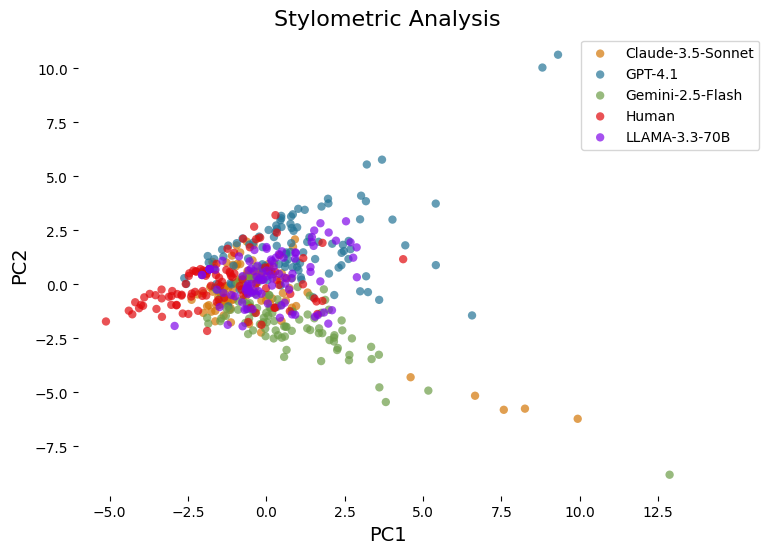

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca_by_source(combined_df, feature_cols=None, title="Stylometric Analysis", annotate=False):
    """
    PCA scatter of numeric features in combined_df, colored by 'source'.
    """
    if 'model_type' not in combined_df.columns:
        raise ValueError("DataFrame must contain a 'model_type' column.")

    # Select features: numeric columns excluding entry_id if present
    if feature_cols is None:
        numeric = combined_df.select_dtypes(include="number").copy()
        if 'entry_id' in numeric.columns:
            numeric = numeric.drop(columns=['entry_id', 'trace_index','total_thoughts_available'])
        feature_cols = numeric.columns.tolist()

    X = combined_df[feature_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_scaled)
    pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
    pc_df['model_type'] = combined_df['model_type'].values
    
    pc_df.to_csv(os.path.join(images_folder, "pc_df.csv"))

    loadings = pd.DataFrame(
        pca.components_.T,  # transpose so features are rows
        columns=['PC1', 'PC2'],
        index=feature_cols
    )

    # Sort by absolute contribution for each PC
    print("Top features driving PC1:")
    print(loadings['PC1'].sort_values(key=abs, ascending=False))

    print("\nTop features driving PC2:")
    print(loadings['PC2'].sort_values(key=abs, ascending=False))

    # Variance explained
    print("\nExplained variance ratio (%):")
    print(pca.explained_variance_ratio_ * 100)


    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = dict(zip(sorted(pc_df['model_type'].unique()), palette5))
    for spine in ax.spines.values():
            spine.set_visible(False)

    for src in sorted(pc_df['model_type'].unique()):
        subset = pc_df[pc_df['model_type'] == src]
        ax.scatter(subset['PC1'], subset['PC2'], label=src, alpha=0.7, edgecolors='none', color=colors[src])
        if annotate:
            for _, row in subset.iterrows():
                ax.annotate(src, (row['PC1'], row['PC2']), fontsize=6, alpha=0.6)

    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f"PC1", fontsize=14)
    ax.set_ylabel(f"PC2", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(title="", bbox_to_anchor=(0.8, 1), loc='upper left', frameon=True)
    # ax.grid(True)
    #plt.tight_layout()

    filename = "stylometric_analysis"
    os.makedirs(images_folder, exist_ok=True)
    plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")

    plt.show()
    


# Example usage:
# Assuming `combined` is your DataFrame from the feature pipeline:
plot_pca_by_source(combined_pca_features)




In [ ]:
palette5 = ['#d47707','#247496','#6c9d47','#e1090d', "#8007e9"]

#F9A845

# FATILURE RATE CALCULATION

In [54]:
def remove_observations(thought_process):
    key_to_remove = 'Observation'
    thoughts_n_actions = [{k: v for k, v in d.items() if k != key_to_remove} for d in thought_process]
    return thoughts_n_actions
        
def add_column_for_thoughts_n_actions(df):
    df["thoughts_n_actions"] = None
    for index, row in df.iterrows():
        tp = row["wtnp_thought_process"]
        if tp != None:
            df["thoughts_n_actions"][index] = remove_observations(tp)
 
# tna == thoughts_n_actions    
add_column_for_thoughts_n_actions(llama_results_filtered)
add_column_for_thoughts_n_actions(gemini_results_filtered)
add_column_for_thoughts_n_actions(claude_results_filtered)
add_column_for_thoughts_n_actions(gpt_results_filtered)

def remove_observations_human(thought_process):
    keys_to_remove = {'observation', 'table'}
    thoughts_n_actions = [
        {k: v for k, v in d.items() if k not in keys_to_remove}
        for d in thought_process
    ]
    return thoughts_n_actions

final_df["thoughts_n_actions"] = None
for index, row in final_df.iterrows():
    tp = row["parsed_thoughtprocess"]
    if tp != None:
        final_df["thoughts_n_actions"][index] = remove_observations_human(tp)


In [19]:
#claude_results_filtered["thoughts_n_actions"][7]

In [55]:
failure_rate_prompt= """You are an expert trace auditor. You will review a single reasoning trace that consists of ordered iterations, where each iteration is a dictionary with keys like Thought, Action, and ActionInput.

Your task: For each of the five phenomena below, count in HOW MANY ITERATIONS it occurs (max 1 per iteration, even if it appears multiple times in that iteration). Return STRICT JSON with integer counts:
{{
  "redirections": <int>,
  "self_monitoring_checks": <int>,
  "forgetting_incidents": <int>,
  "invalid_tool_calls": <int>,
  "repeated_tool_calls_due_to_bad_input": <int>
}}

Important constraints:
- Work iteration by iteration. For each iteration, set boolean flags for each phenomenon, then sum across iterations.
- Do NOT count more than once per phenomenon within a single iteration.
- Prefer explicit textual evidence over inference. Use the “Thought” first; use “Action”/“ActionInput” to confirm or detect tool-related issues.
- If two phenomena could apply, both can be true in the SAME iteration (e.g., a self-monitoring statement followed by a redirection).
- Be cautious but not overly conservative: use the cue lists and definitions below.

Trace:
f"{TRACE}\n\n"

==============================
DEFINITIONS + CUE CHECKLISTS
==============================

1) Redirection of thought  (strategy shift after failure/ambiguity)
Count when the Thought explicitly signals a change in approach BECAUSE something didn’t work, was ambiguous, or lacked evidence.
Strong positive cues (any of these words/phrases nearly always count):
- "instead", "switch", "change strategy", "pivot", "refocus", "new approach"
- "I should try", "I'll try", "let me try", "next I'll try", "I'll look for", "I will search for X instead"
- "that didn’t work", "not useful", "no results", "too broad", "failed", "error", "out of memory"
Counter-cues (do NOT count if only these apply):
- Generic progress like "next", "then", "also" without linking to a failed/ambiguous prior step.
- Merely continuing the same approach without acknowledging the prior issue.

2) Self-monitoring (meta-reasoning checks)
Count when the Thought explicitly evaluates or questions its own intermediate results or reasoning.
Strong positive cues:
- "let me double-check", "verify", "confirm", "cross-check", "sanity check"
- "seems inconsistent", "uncertain", "I should verify whether", "none of these seem directly related", "likely incorrect"
- "this result may be wrong/insufficient/ambiguous"
Counter-cues:
- Pure narration of facts or next steps with no evaluative language.
- Generic summaries without a check or critique.

3) Forgetting (ignoring earlier relevant info)
Count when the agent previously obtained/stated important info and later behaves as if unaware, omits it in a way that contradicts constraints, or re-searches for the exact item without acknowledgment.
Positive patterns:
- Re-asking for a fact already found, with no reference to having found it.
- Violating a previously stated constraint or condition and proceeding as if it never existed.
- Discarding earlier key evidence without acknowledgment and repeating the same lookup.
Counter-cues:
- Revisiting with explicit acknowledgment ("re-check", "confirm earlier value", "update prior finding").
- Refining a query (counts as redirection, not forgetting) when it clearly builds on the prior result.

4) Incorrect tool call / invalid tool invocation
Count when the Action clearly could not succeed due to malformed invocation OR misunderstanding of tool purpose/contract.
Positive patterns:
- Nonexistent tool name (typo or unknown tool).
- Invalid/missing required parameters; syntactically invalid args for that tool.
- Clear misuse of the tool’s purpose (e.g., using a gene-retrieval tool to fetch chemical dyes), when the Thought/Action shows the intent is outside the tool’s designed scope.
Counter-cues:
- A tool error caused by external limits (e.g., "CUDA out of memory") is NOT automatically invalid.
- Broad queries that return few/irrelevant results are NOT automatically invalid (may indicate redirection or poor input instead).

5) Repeated tool call due to poor action input
Count when essentially the same tool is called repeatedly with the same or trivially varied input, soon after, WITHOUT a justified change in context, and the repetition appears to be caused by an ineffective prior input.
Positive patterns:
- Same tool + same or near-identical query multiple times, no refinement, no rationale.
- "Search X", then "Search X again", or "Search X!!!" without added constraints or explanation.
Counter-cues:
- Repeating a tool AFTER stating a rationale for refinement or error handling (e.g., "previous search was too broad; I'll narrow to 'membrane potential dyes'") — this is a justified redirection, not a penalized repetition.
- Using different tools or clearly different/meaningfully refined inputs.

==============================
SCORING PROCEDURE (do this mentally; ONLY OUTPUT JSON)
==============================
For each iteration i:
  Initialize flags: R,S,F,I,P = False  # redirections, self_monitoring_checks, forgetting_incidents, invalid_tool_calls, repeated_tool_calls_due_to_bad_input
  1) Read Thought[i]. If it contains strong redirection cues tied to a prior failure/ambiguity → R=True.
  2) If Thought[i] contains explicit evaluation/verification language → S=True.
  3) Compare with earlier iterations: if the agent ignores/contradicts earlier known key info or re-asks for it with no acknowledgment → F=True.
  4) Inspect Action[i]/ActionInput[i]: if malformed or clearly misuses the tool per definition → I=True.
  5) Compare Action[i] with recent actions: if same tool + same/nearly same input repeated without justification → P=True.
After all iterations, sum R,S,F,I,P across i.
Output STRICT JSON with the five integer fields, and nothing else.

==============================
OUTPUT FORMAT (STRICT)
==============================
{{
  "redirections": <integer>,
  "self_monitoring_checks": <integer>,
  "forgetting_incidents": <integer>,
  "invalid_tool_calls": <integer>,
  "repeated_tool_calls_due_to_bad_input": <integer>
}}


"""

In [56]:
# failure_rate_prompt="""You are an expert trace auditor. Below is one full reasoning trace containing iterations of (Thought → Action → ActionInput) on a research task. Each step is labeled and in order. Each iteration is represented as one dictionary object in the trace.

# Your job is to analyze the trace and determine, for each of the five listed phenomena, how many **iterations** it occurs in. You must return the **number of iterations** in which each phenomenon occurs — not the total number of times the phenomenon appears.

# 🔸 Count at most one occurrence of a given phenomenon per iteration, even if it appears multiple times within a single iteration.

# Use the definitions and examples to guide your judgments. Return only a JSON object with integer counts — where each value represents the number of **iterations** in which that phenomenon occurred.

# Trace:
# f"{TRACE}\n\n"

# Definitions (apply these as carefully as you can):

# 1. "Redirection of thought": A deliberate, explicit change in strategy after encountering failure, ambiguity, or missing evidence. 
#    Example: "That source didn't yield anything useful; instead, I'll try searching for X" or "Given that the previous approach failed, switch to looking at Y."

# 2. "Self-monitoring": Explicit internal checks or meta-statements where the agent questions, verifies, or reflects on its own reasoning or intermediate results.
#    Example: "Let me double-check that value," "I should verify whether this claim is supported," "This seems inconsistent—I'll cross-reference it."

# 3. "Forgetting": The agent previously acquired or mentioned important information relevant to the task and then later acts as if unaware of it, or fails to incorporate it when it should have. 
#    Example: Finding a key piece of evidence early but later re-searching for the same fact without acknowledging it, or ignoring a constraint previously stated and proceeding as if it were unknown.

# 4. "Incorrect tool call / invalid tool invocation": Attempts to invoke a tool that is malformed, refers to a non-existent tool (e.g., typo in tool name), uses wrong interface/arguments in a way that is clearly incompatible with the intended tool, or demonstrates misunderstanding of the tool’s purpose leading to a call that would not succeed. 
#    Example: Calling "Seaerch" instead of "Search", passing multiple unrelated questions to a tool that expects one, or invoking a tool with syntactically invalid parameters.

# 5. "Repeated tool call due to poor action input": Reissuing the same or very similar tool call (query or target) multiple times in succession or shortly after, without a justified change in context, where the repetition appears caused by an ineffective or malformed previous action input (e.g., search query was too vague, malformed, or nonsensical and the agent retries essentially the same bad input instead of adjusting strategy). 
#    Example: Searching "best vaccine trials" three times in a row with no refinement after getting no useful result, or re-requesting the same document lookup without incorporating new understanding.

# Response format (strict JSON, no extra text):
# {{
#   "redirections": <integer>,
#   "self_monitoring_checks": <integer>,
#   "forgetting_incidents": <integer>,
#   "invalid_tool_calls": <integer>,
#   "repeated_tool_calls_due_to_bad_input": <integer>
# }}
# """

In [22]:
prompt_final=failure_rate_prompt.format(TRACE = llama_results_filtered["thoughts_n_actions"][0])

In [ ]:

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
                    model_name="meta-llama/Llama-3.3-70B-Instruct",
                    base_url="https://llm.scads.ai/v1",
                    openai_api_key=os.environ.get("SCADS_API_KEY"),
                    temperature=0,
                    timeout=300,
                )
                
response=llm.invoke(prompt_final)

In [68]:
response

AIMessage(content='```json\n{\n  "redirections": 3,\n  "self_monitoring_checks": 3,\n  "forgetting_incidents": 0,\n  "invalid_tool_calls": 0,\n  "repeated_tool_calls_due_to_bad_input": 1\n}\n```', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 2186, 'total_tokens': 2245, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'hosted_vllm/meta-llama/Llama-3.3-70B-Instruct', 'system_fingerprint': None, 'id': 'chatcmpl-dd98f0d8ae1d49b7b0c453ed2a4efd10', 'finish_reason': 'stop', 'logprobs': None}, id='run--b50dcbde-ad06-486b-b6f9-8a977af541ee-0', usage_metadata={'input_tokens': 2186, 'output_tokens': 59, 'total_tokens': 2245, 'input_token_details': {}, 'output_token_details': {}})

In [ ]:
import re
import time
from langchain_openai import ChatOpenAI

def chat_with_llama(full_text):
    if full_text == None or full_text == "":
        return {'redirections': -10,
                'self_monitoring_checks': -10,
                'forgetting_incidents': -10,
                'invalid_tool_calls': -10,
                'repeated_tool_calls_due_to_bad_input': -10}
    final_prompt=failure_rate_prompt.format(TRACE = full_text)
    #print(failure_rate_prompt)
    
    for attempt in range(3):
        try:
            llm = ChatOpenAI(
                                model_name="gpt-5-mini-2025-08-07",
                                #base_url="https://llm.scads.ai/v1",
                                openai_api_key=os.environ.get("OPENAI_API_KEY"),
                                #temperature=0,
                                timeout=300,
                            )
                            
            response=llm.invoke(final_prompt)
            
            content = response.content
            match = re.search(r"\{.*\}", content, re.DOTALL)
            if match:
                return json.loads(match.group(0))
        except Exception as e:
            print(f"LLaMA attempt {attempt+1} failed: {e}")
            time.sleep(1)
    return {}


In [58]:
final_df.columns

Index(['id', 'Name', 'category', 'question', 'thoughtprocess', 'final_answer',
       'must_have_statements', 'nice_have_statements', 'parsed_thoughtprocess',
       'total_intermediate_steps', 'all_tools_list', 'model_type',
       'thoughts_n_actions'],
      dtype='object')

In [59]:
final_df["category"].value_counts()

category
Causation/Reasoning        9
Application/Implication    8
Synthesis/Review           8
Defintion/Background       6
Process/Mechanism          4
Evaluation/Comparison      4
Name: count, dtype: int64

In [60]:
human_failure_rate_df = (
    final_df.groupby("category", group_keys=False)
      .apply(lambda x: x.sample(n=4, random_state=42))
)

selected_ids = human_failure_rate_df["id"].tolist()

llama_failure_rate_df = llama_results_filtered[llama_results_filtered["id"].isin(selected_ids)]
gpt_failure_rate_df = gpt_results_filtered[gpt_results_filtered["id"].isin(selected_ids)]
claude_failure_rate_df = claude_results_filtered[claude_results_filtered["id"].isin(selected_ids)]
gemini_failure_rate_df = gemini_results_filtered[gemini_results_filtered["id"].isin(selected_ids)]

In [33]:
selected_ids

[18,
 44,
 17,
 58,
 53,
 11,
 35,
 9,
 1,
 3,
 61,
 4,
 15,
 56,
 14,
 16,
 7,
 52,
 6,
 8,
 23,
 48,
 21,
 60]

In [32]:
subset

,id,category
0,1,Defintion/Background
1,3,Defintion/Background
2,4,Defintion/Background
3,6,Process/Mechanism
4,7,Process/Mechanism
5,8,Process/Mechanism
6,9,Causation/Reasoning
7,11,Causation/Reasoning
9,14,Evaluation/Comparison
10,15,Evaluation/Comparison


In [61]:
import pandas as pd

def get_failure_rates_outputs(df):

    results = df['thoughts_n_actions'].apply(chat_with_llama)
    results_df = pd.json_normalize(results)
    results_df.index = df.index  
    final_results_df = pd.concat([df[['id', 'thoughts_n_actions', 'model_type']], results_df], axis=1)
    return final_results_df

llama_failure_rates_df_scores = get_failure_rates_outputs(llama_failure_rate_df)
gpt_failure_rates_df_scores = get_failure_rates_outputs(gpt_failure_rate_df)
claude_failure_rates_df_scores = get_failure_rates_outputs(claude_failure_rate_df)
gemini_failure_rates_df_scores = get_failure_rates_outputs(gemini_failure_rate_df)
human_failure_rates_df_scores = get_failure_rates_outputs(human_failure_rate_df)

In [62]:
import pandas as pd

model_dfs = pd.concat([llama_failure_rates_df_scores, claude_failure_rates_df_scores,gpt_failure_rates_df_scores, gemini_failure_rates_df_scores ,human_failure_rates_df_scores], axis=0)

model_dfs.to_csv(os.path.join(images_folder, "failure_rates.csv"))

metric_columns = [col for col in model_dfs.columns if col not in ['model_type', 'id', 'thoughts_n_actions']]

model_metrics_summary = (
    model_dfs.groupby('model_type')[metric_columns]
    .mean()
    .to_dict(orient='index')
)

# Result
print(model_metrics_summary)


{'Claude-3.5-Sonnet': {'redirections': 4.708333333333333, 'self_monitoring_checks': 5.75, 'forgetting_incidents': 0.08333333333333333, 'invalid_tool_calls': 0.7083333333333334, 'repeated_tool_calls_due_to_bad_input': 1.5}, 'GPT-4.1': {'redirections': 4.958333333333333, 'self_monitoring_checks': 6.041666666666667, 'forgetting_incidents': 0.0, 'invalid_tool_calls': 0.041666666666666664, 'repeated_tool_calls_due_to_bad_input': 0.0}, 'Gemini-2.5-Pro': {'redirections': 3.5, 'self_monitoring_checks': 4.791666666666667, 'forgetting_incidents': 0.041666666666666664, 'invalid_tool_calls': 0.08333333333333333, 'repeated_tool_calls_due_to_bad_input': 0.041666666666666664}, 'Human': {'redirections': 1.1666666666666667, 'self_monitoring_checks': 1.5833333333333333, 'forgetting_incidents': 0.041666666666666664, 'invalid_tool_calls': 0.0, 'repeated_tool_calls_due_to_bad_input': 0.0}, 'LLAMA-3.3-70B': {'redirections': 2.6666666666666665, 'self_monitoring_checks': 3.9583333333333335, 'forgetting_incide

In [ ]:
# import pandas as pd

# model_dfs = pd.concat([llama_failure_rates_df_scores, claude_failure_rates_df_scores,gpt_failure_rates_df_scores, gemini_failure_rates_df_scores ,human_failure_rates_df_scores], axis=0)

# model_dfs.to_csv(os.path.join(images_folder, "failure_rates.csv"))

# metric_columns = [col for col in model_dfs.columns if col not in ['model_type', 'id', 'thoughts_n_actions']]

# model_metrics_summary = (
#     model_dfs.groupby('model_type')[metric_columns]
#     .mean()
#     .to_dict(orient='index')
# )

# # Result
# print(model_metrics_summary)


{'Claude-3.5-Sonnet': {'redirections': 3.3333333333333335, 'self_monitoring_checks': 1.25, 'forgetting_incidents': 0.4583333333333333, 'invalid_tool_calls': 0.08333333333333333, 'repeated_tool_calls_due_to_bad_input': 1.5}, 'GPT-4.1': {'redirections': 3.7083333333333335, 'self_monitoring_checks': 1.25, 'forgetting_incidents': 0.0, 'invalid_tool_calls': 0.041666666666666664, 'repeated_tool_calls_due_to_bad_input': 1.375}, 'Gemini-2.5-Pro': {'redirections': 2.9583333333333335, 'self_monitoring_checks': 1.2083333333333333, 'forgetting_incidents': 0.0, 'invalid_tool_calls': 0.041666666666666664, 'repeated_tool_calls_due_to_bad_input': 1.0833333333333333}, 'Human': {'redirections': 1.0, 'self_monitoring_checks': 0.20833333333333334, 'forgetting_incidents': 0.041666666666666664, 'invalid_tool_calls': 0.0, 'repeated_tool_calls_due_to_bad_input': 0.5416666666666666}, 'LLAMA-3.3-70B': {'redirections': 2.125, 'self_monitoring_checks': 0.3333333333333333, 'forgetting_incidents': 0.125, 'invalid_t

In [76]:
model_dfs.columns

Index(['id', 'thoughts_n_actions', 'model_type', 'redirections',
       'self_monitoring_checks', 'forgetting_incidents', 'invalid_tool_calls',
       'repeated_tool_calls_due_to_bad_input'],
      dtype='object')

In [81]:
model_dfs['model_type'].unique()

array(['LLAMA-3.3-70B', 'Claude-3.5-Sonnet', 'GPT-4.1', 'Gemini-2.5-Pro',
       'Human'], dtype=object)

In [78]:
print(min(model_dfs['redirections']), min(model_dfs['self_monitoring_checks']), min(model_dfs['forgetting_incidents']), min(model_dfs['invalid_tool_calls']), min(model_dfs['repeated_tool_calls_due_to_bad_input']))

0 0 0 0 0


In [82]:
claude_values = list(model_metrics_summary['Claude-3.5-Sonnet'].values())
gpt_values = list(model_metrics_summary['GPT-4.1'].values())
gemini_values = list(model_metrics_summary['Gemini-2.5-Pro'].values())
human_values = list(model_metrics_summary['Human'].values())
llama_values = list(model_metrics_summary['LLAMA-3.3-70B'].values())


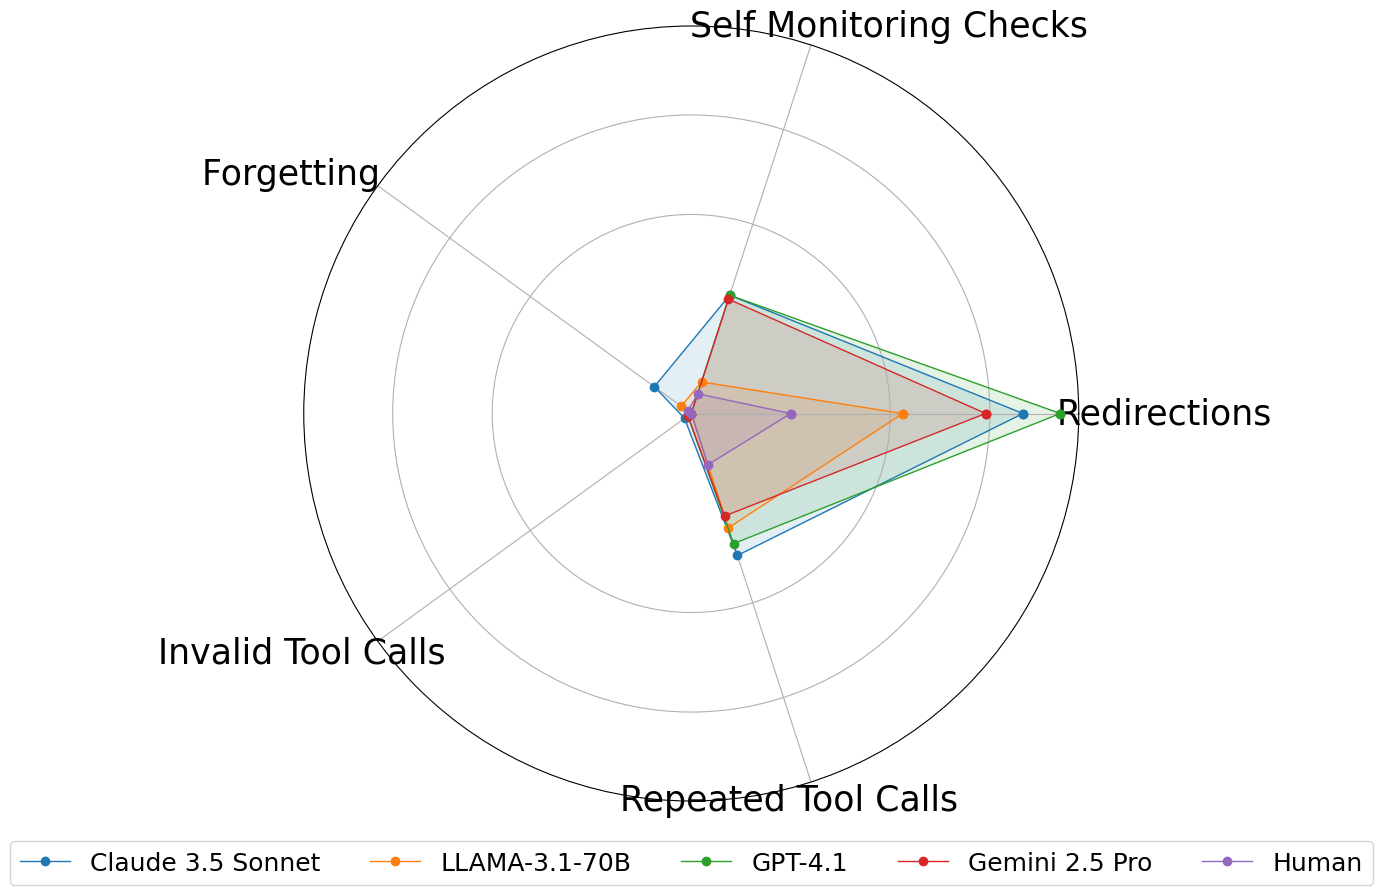

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
labels = ['            Redirections', '             Self Monitoring Checks', 'Forgetting             ', 'Invalid Tool Calls           ', '           Repeated Tool Calls                ']
num_vars = len(labels)

# Example data for different lines on the radar chart
data = [
    claude_values,
    llama_values,
    gpt_values,
    gemini_values,
    human_values
]

# Corresponding labels for the data
legend_labels = ['Claude 3.5 Sonnet', 'LLAMA-3.1-70B', 'GPT-4.1','Gemini 2.5 Pro','Human']

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Repeat the first value to close the circle
data = [d + [d[0]] for d in data]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10,13), subplot_kw=dict(polar=True))

# Draw one axe per variable and add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=25)

#Draw ylabels
ax.set_rscale('linear')
ax.set_yticks([2,3,4])
ax.set_yticklabels([ '', '',''])

# Plot data
for idx, d in enumerate(data):
    ax.plot(angles, d, linewidth=1, linestyle='solid',marker='o', label=legend_labels[idx])
    ax.fill(angles, d, alpha=0.12)

# Add a legend
# plt.title("Evaluation of generated reports with Claude 3.5 Sonnet", y = 1.05, fontsize = 28)
ax.legend(loc='center', bbox_to_anchor=(0.5, -0.08),  ncol=5, fontsize = 18)
filename = "failure_rates"
os.makedirs(images_folder, exist_ok=True)
plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")
plt.show()



# Verbosity vs Accuracy score 

In [ ]:
# %%
import pandas as pd
import numpy as np
from typing import Dict

# ---------- Provided scoring functions (verbatim, with tiny safety tweaks) ----------
def calculate_unified_score(
    rouge_1, 
    rouge_2, 
    rouge_L, 
    bleu_score, 
    bert_score, 
    must_have_confidence, 
    nice_to_have_confidence,
    weights: Dict[str, float] = None,
    *,
    bert_calibration=(0.85, 0.99),    # map this BERTScore range -> [0,1]
    must_have_gate=0.60,              # hard gate: below this, adjusted score = 0
    gate_gamma=2.0,                   # smooth multiplier strength above the gate
) -> dict:
    """
    Unified score with:
      - Defensive normalization/clamping
      - Calibrated semantic score
      - Combined lexical overlap (ROUGE + BLEU) via geometric mean
      - Hard + multiplicative gating on must-haves
      - Weight renormalization
    """
    # -------- helpers
    def clamp01(x): 
        return max(0.0, min(1.0, float(x)))

    # Fill missing ROUGE keys with 0
    r1 = clamp01(rouge_1)
    r2 = clamp01(rouge_2)
    rL = clamp01(rouge_L)

    # Normalize BLEU to [0,1] if provided as percentage
    bleu = bleu_score / 100.0 if bleu_score > 1.0 else clamp01(bleu_score)

    # # Calibrate BERTScore into [0,1] (prevents narrow-range dominance)
    # b_lo, b_hi = bert_calibration
    # if b_hi <= b_lo:
    #     raise ValueError("bert_calibration must have hi > lo")
    # bert_cal = clamp01((bert_score - b_lo) / (b_hi - b_lo))

    # Combine ROUGE into a single score (favor sequence match)
    rouge_combined = 0.4 * rL + 0.3 * r2 + 0.3 * r1

    # Combine lexical into ONE signal (punish imbalance) via geometric mean
    # add tiny epsilon to avoid 0 product
    eps = 1e-8
    lexical = ((rouge_combined + eps) * (bleu + eps)) ** 0.5

    # Default weights (will be renormalized to sum to 1)
    if weights is None:
        weights = {
            'must_have': 0.50,     # critical: coverage dominates
            'semantic':  0.25,     # calibrated BERTScore
            'lexical':   0.15,     # combined ROUGE/BLEU
            'nice_to_have': 0.10,  # extras
        }

    # Renormalize weights to sum to 1
    total_w = sum(weights.values())
    if total_w <= 0:
        raise ValueError("Weights must sum to a positive value.")
    wn = {k: v / total_w for k, v in weights.items()}

    # Clamp coverages
    mh = clamp01(must_have_confidence)
    nth = clamp01(nice_to_have_confidence)

    # Component contributions
    component_scores = {
        'must_have_component': mh * wn['must_have'],
        'semantic_component':  bert_score * wn['semantic'],
        'lexical_component':   lexical * wn['lexical'],
        'nice_to_have_component': nth * wn['nice_to_have'],
    }

    raw_unified = sum(component_scores.values())

    # ---- Gating: if must-haves below threshold, the adjusted score is 0
    gating_reason = None
    if mh < must_have_gate:
        adjusted = 0.0
        gating_reason = f"must_have_confidence {mh:.2f} < gate {must_have_gate:.2f}"
        multiplier = 0.0
    else:
        # Smooth multiplicative boost above gate; in [0,1]
        # When mh == gate -> multiplier=0 ; when mh==1 -> multiplier=1
        numerator = mh - must_have_gate
        denominator = 1.0 - must_have_gate
        base = max(0.0, numerator / denominator)
        multiplier = base ** gate_gamma
        adjusted = raw_unified * multiplier

    # Qualitative label
    #interpretation = get_score_interpretation(adjusted)

    return {
        'unified_score_raw': raw_unified,
        'adjusted_score': adjusted,
        'multiplier_from_must_have': multiplier,
        'gating_reason': gating_reason,
        'component_scores': component_scores,
        'details': {
            'rouge_combined': rouge_combined,
            'bleu_norm': bleu,
            'lexical_combined': lexical,
            #'bert_calibrated': bert_cal,
            'weights_used': wn,
            'params': {
                'bert_calibration': bert_calibration,
                'must_have_gate': must_have_gate,
                'gate_gamma': gate_gamma
            }
        },
        #'interpretation': interpretation,
        'must_have_coverage': mh,
        'nice_to_have_coverage': nth
    }

def get_score_interpretation(score: float) -> str:
    if score >= 0.85:
        return "Excellent — very strong match with requirements"
    elif score >= 0.70:
        return "Good — most requirements met with strong similarity"
    elif score >= 0.55:
        return "Acceptable — core requirements mostly met, some gaps"
    elif score >= 0.40:
        return "Below Expected — missing important requirements"
    else:
        return "Poor — significant gaps in requirements and content"

# ---------- Load the uploaded file ----------
df = pd.read_csv(f"{EVAL_OUTPUT_DIR}/evaluation_without_averages.csv", header=0)

numeric_df = df.copy()
numeric_df["unified_score_raw"] = None
numeric_df["adjusted_score"] = None

for idx, row in numeric_df.iterrows():
    rouge_1 = row["wtp_rouge1"] 
    rouge_2 = row["wtp_rouge2"]
    rouge_L = row["wtp_rougeL"]
    bert_score = row["wtp_bertscore_F1"]
    bleu = row["wtp_bleu"]
    must_have = row["wtp_must_have_score"]
    nice_to_have = row["wtp_nice_to_have_score"]
    res = calculate_unified_score(rouge_1, rouge_2, rouge_L, bleu, bert_score, must_have, nice_to_have)
    numeric_df["unified_score_raw"][idx] = res['unified_score_raw']
    numeric_df["adjusted_score"][idx] = res['adjusted_score']


# # Save output
# out_path = "/mnt/data/evaluation_with_unified_scores.csv"
# numeric_df.to_csv(out_path, index=False)


In [79]:
numeric_df=numeric_df.rename(columns={
        "model": "model_type",
    })

In [80]:

combined_df_without_humans_data = combined_df[combined_df['model_type'] != 'Human']


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

verbosity_df = pd.DataFrame()

# Compute tokens per step
# df = df[df["total_intermediate_steps"] > 0].copy()

verbosity_df = combined_df_without_humans_data[['id','model_type','formatted_TP_tokens', 'total_intermediate_steps']].copy()
verbosity_df["tokens_per_step"] = None

verbosity_df["formatted_TP_tokens"] = pd.to_numeric(verbosity_df["formatted_TP_tokens"], errors="coerce")
verbosity_df["total_intermediate_steps"] = pd.to_numeric(verbosity_df["total_intermediate_steps"], errors="coerce")


verbosity_df["tokens_per_step"] = (
    verbosity_df["formatted_TP_tokens"] /
    verbosity_df["total_intermediate_steps"]
)
verbosity_df.loc[~np.isfinite(verbosity_df["tokens_per_step"]), "tokens_per_step"] = np.nan  # inf/-inf -> NaN


############################################################
# Model mapping
model_map = {
    "GPT-4.1": "gpt",
    "LLAMA-3.1-70B": "llama",
    "Claude 3.5 Sonnet": "claude",
    "Gemini 2.5 Flash": "gemini"
}

# # Apply mapping to verbosity_df
# verbosity_df = verbosity_df.copy()
# numeric_df   = numeric_df.copy()

# verbosity_df["id"] = verbosity_df["id"].astype(str)
# numeric_df["id"]   = numeric_df["id"].astype(str)

# Create a normalized model_family column
verbosity_df["model_family"] = verbosity_df["model_type"].map(model_map)

# numeric_df already has the simplified names, so just reuse model_type as family
numeric_df["model_family"] = numeric_df["model_type"]

# Merge
verbosity_accuracy_df = verbosity_df.merge(
    numeric_df[["id", "model_family", "unified_score_raw", "adjusted_score"]],
    on=["id", "model_family"],
    how="left"
)
###########################################################

# Optional: standardize score if on different scales (skip if already comparable)
# df["score_z"] = (df["score"] - df["score"].mean()) / df["score"].std()


In [82]:
verbosity_accuracy_df

,id,model_type,formatted_TP_tokens,total_intermediate_steps,tokens_per_step,model_family,unified_score_raw,adjusted_score
0,1,GPT-4.1,10771.0,7.0,1538.714286,gpt,0.117981,0.0
1,3,GPT-4.1,8281.0,12.0,690.083333,gpt,0.460727,0.0
2,4,GPT-4.1,9929.0,13.0,763.769231,gpt,0.707037,0.707037
3,6,GPT-4.1,11104.0,8.0,1388.000000,gpt,0.630733,0.630733
4,7,GPT-4.1,8367.0,9.0,929.666667,gpt,0.704472,0.704472
...,...,...,...,...,...,...,...,...
63,18,Gemini 2.5 Pro,6337.0,7.0,905.285714,NaN,NaN,NaN
64,21,Gemini 2.5 Pro,11454.0,9.0,1272.666667,NaN,NaN,NaN
65,23,Gemini 2.5 Pro,11763.0,10.0,1176.300000,NaN,NaN,NaN
66,24,Gemini 2.5 Pro,11817.0,13.0,909.000000,NaN,NaN,NaN


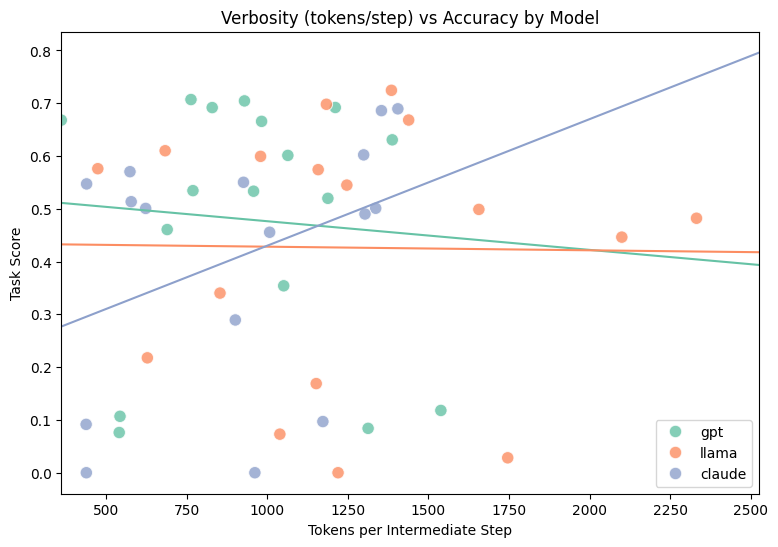

In [84]:
import numpy as np

# Scatter plot: tokens_per_step vs score, colored by model
plt.figure(figsize=(9,6))

# for spine in ax.spines.values():
#     spine.set_visible(False)

# build a palette that matches hue categories in order of appearance
models = list(verbosity_accuracy_df["model_family"].dropna().unique())
palette = dict(zip(models, sns.color_palette("Set2", n_colors=len(models))))

ax = sns.scatterplot(
    data=verbosity_accuracy_df,
    x="tokens_per_step",
    y="unified_score_raw",
    hue="model_family",
    hue_order=models,
    alpha=0.8,
    s=80,                    # smaller dots
    palette=palette
)

# make reg lines span the whole x-range of the plot
x_min = np.nanmin(verbosity_accuracy_df["tokens_per_step"])
x_max = np.nanmax(verbosity_accuracy_df["tokens_per_step"])
ax.set_xlim(x_min, x_max)

# Fit and plot regression line for each model, colored to match scatter
for m in models:
    subset = verbosity_accuracy_df[verbosity_accuracy_df["model_family"] == m]
    if len(subset) >= 5:  # enough points to fit
        sns.regplot(
            data=subset,
            x="tokens_per_step",
            y="unified_score_raw",
            scatter=False,
            #label=f"{m} trend",
            ci=None,
            line_kws={"linewidth":1.5},
            color=palette[m],      # match colors
            truncate=False,        # extend line to axis limits
            ax=ax
        )

plt.xlabel("Tokens per Intermediate Step")
plt.ylabel("Task Score")
plt.title("Verbosity (tokens/step) vs Accuracy by Model")
#plt.legend(bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.legend(loc="lower right")
# plt.grid(alpha=0.3)
# plt.tight_layout()

filename = "Verbosity_accuracy"
os.makedirs(images_folder, exist_ok=True)
plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")
plt.show()


# Tools - Model behaviour (Swiss army knife / Single hammer) per model heatmap

In [96]:
from matplotlib.colors import LinearSegmentedColormap
# Your custom palette
palette3 = ["#c7f9cc", "#80ed99", "#57cc99","#38a3a5", "#22577a"]
palette4 = ["#ebfffb","#d8f4ed","#c4e8de","#85f2cc","#45fcba","#1ce3a4","#0f986d","#014c35","#001e15"]
# Create a continuous colormap from your colors
custom_cmap = LinearSegmentedColormap.from_list("custom_heatmap", palette4)

In [97]:
#tool_df_raw=combined_df.drop(index=[0,3])

In [98]:
#tool_df_raw = combined_df.drop(columns="tools_used")
tool_df_raw = combined_df.rename(columns={'model_type': 'model', 'id': 'entry_id', "all_tools_list":"tools_used"})

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # optional for nicer visuals
from collections import Counter
from scipy.stats import entropy

In [100]:
FULL_TOOL_LIST = [
    "Retrieve_ClinVar", 
    "Summarize_CliVar_Page", 
    "Retrieve_Gene",
    "Summarize_Gene_Page",
    "Retrieve_KEGG",
    "Summarize_KEGG_Page",
    "Retrieve_PubMed",
    "Summarize_PubMedCentral_Page",
    "Retrieve_UniProt_Page",
    "Summarize_UniProt_Page",
    "Exchange_PMC_PMID",
    "Fetch_Info_Any_Source"]

SHORT_LABELS = [
    "RCl",  # Retrieve_ClinVar
    "SCl",  # Summarize_CliVar_Page
    "RGe",  # Retrieve_Gene
    "SGe",  # Summarize_Gene_Page
    "RKe",  # Retrieve_KEGG
    "SKe",  # Summarize_KEGG_Page
    "RPm",  # Retrieve_PubMed
    "SPm",  # Summarize_PubMedCentral_Page
    "RUp",  # Retrieve_UniProt_Page
    "SUp",  # Summarize_UniProt_Page
    "Ex",  # Exchange_PMC_PMID
    "FIn"   # Fetch_Info_Any_Source
]



In [101]:
from itertools import chain

human_tools = set(chain.from_iterable(
    tool_df_raw.loc[tool_df_raw["model"]=="Human", "tools_used"]
))
print("Tools in human data:", human_tools)

# Compare to your FULL_TOOL_LIST
missing = [t for t in human_tools if t not in FULL_TOOL_LIST]
extra  = [t for t in FULL_TOOL_LIST if t not in human_tools]
print("In data but NOT in FULL_TOOL_LIST:", missing)
print("In FULL_TOOL_LIST but NOT in data:", extra)

Tools in human data: {'PubMedCentral_Summarize', 'PubMed_Retrieve', 'KEGG_Retrieve', 'Fetch_Info_Any', 'KEGG_Summarize_Page', 'Gene_Summarize_Page', 'Gene_Retrieve', 'Exchange_PMCID_PMID', 'UniProt_Retrieve', 'UniProt_Summarize_Page'}
In data but NOT in FULL_TOOL_LIST: ['PubMedCentral_Summarize', 'PubMed_Retrieve', 'KEGG_Retrieve', 'Fetch_Info_Any', 'KEGG_Summarize_Page', 'Gene_Summarize_Page', 'Gene_Retrieve', 'Exchange_PMCID_PMID', 'UniProt_Retrieve', 'UniProt_Summarize_Page']
In FULL_TOOL_LIST but NOT in data: ['Retrieve_ClinVar', 'Summarize_CliVar_Page', 'Retrieve_Gene', 'Summarize_Gene_Page', 'Retrieve_KEGG', 'Summarize_KEGG_Page', 'Retrieve_PubMed', 'Summarize_PubMedCentral_Page', 'Retrieve_UniProt_Page', 'Summarize_UniProt_Page', 'Exchange_PMC_PMID', 'Fetch_Info_Any_Source']


In [102]:

# Create mapping for legend
TOOL_LEGEND = dict(zip(SHORT_LABELS, FULL_TOOL_LIST))

# Allow customization of x-axis order (modify this list to reorder)
X_AXIS_ORDER = X_AXIS_ORDER = [ "Ex", "FIn", "RGe","SGe", "RUp", "SUp","RCl","SCl", "RKe", "SKe", "RPm", "SPm"]#SHORT_LABELS.copy()  # Change this to reorder items
# Example: X_AXIS_ORDER = ["RPM", "RCV", "RGE", "RKG", "RUP", "SCV", "SGE", "SKG", "SPC", "SUP", "EPM", "FIA"]

# Define tool groups - customize these based on your needs
# TOOL_GROUPS = {
#     "Retrieval Tools": ["Ex", "RGe", "RUp", "RCl", "RKe", "RPm"],
#     "Summarization Tools": ["FIn","SGe", "SUp", "SCl", "SKe", "SPm"]
# }

TOOL_GROUPS = {
    "Structured Tools": ["Ex", "RGe", "SGe","RUp","SUp", "RCl","SCl", "RKe", "SKe",],
    "Unstructured Tools": ["FIn", "RPm", "SPm"]
}

CANONICAL = {
    "PubMed_Retrieve":           "Retrieve_PubMed",
    "KEGG_Retrieve":             "Retrieve_KEGG",
    "Gene_Retrieve":             "Retrieve_Gene",
    "UniProt_Retrieve":          "Retrieve_UniProt_Page",
    "Exchange_PMCID_PMID":       "Exchange_PMC_PMID",
    "Fetch_Info_Any":            "Fetch_Info_Any_Source",
    "PubMedCentral_Summarize":   "Summarize_PubMedCentral_Page",
    "KEGG_Summarize_Page":       "Summarize_KEGG_Page",
    "Gene_Summarize_Page":       "Summarize_Gene_Page",
    "UniProt_Summarize_Page":    "Summarize_UniProt_Page",
}

In [103]:
tool_df_raw[tool_df_raw["tools_used"].isnull()].index

Index([], dtype='int64')

In [104]:
tool_df_raw.shape

(195, 36)

In [105]:
tool_df_raw["tools_used"] = tool_df_raw["tools_used"].apply(
    lambda lst: [ CANONICAL.get(t, t) for t in lst ]
)

In [106]:
all_models = tool_df_raw["model"].unique()
all_models

array(['GPT-4.1', 'LLAMA-3.3-70B', 'Claude-3.5-Sonnet', 'Gemini-2.5-Pro',
       'Human'], dtype=object)

In [107]:
MODEL_LEGEND = {
    "Human": "H",
    "GPT-4.1": "Gpt",
    "LLAMA-3.3-70B": "L",
    "Claude-3.5-Sonnet": "C",
    "Gemini-2.5-Pro": "Ge",
}

In [ ]:


# # ---------------------------
# # NORMALIZE: ensure every (model, entry_id) pair exists; missing => tools_used = []
# all_models = tool_df_raw["model"].unique()
# all_entry_ids = tool_df_raw["entry_id"].unique()
# full_index = pd.MultiIndex.from_product(
#     [all_entry_ids, all_models],
#     names=["entry_id", "model"]
# )
# # Reindex to full grid
# tool_df = (
#     tool_df_raw
#     .set_index(["entry_id", "model"])
#     .reindex(full_index, fill_value=None)
#     .reset_index()
# )
# # Replace None tools_used with empty list
# tool_df["tools_used"] = tool_df["tools_used"].apply(lambda x: x if isinstance(x, list) else [])

# # ---------------------------
# # Precompute per-row Counter and total calls
# tool_df["tool_counter"] = tool_df["tools_used"].apply(Counter)
# tool_df["total_calls"] = tool_df["tools_used"].apply(len)

# # ---------------------------
# # 1. Breadth: proportion of entries per model that use each tool at least once
# entries_per_model = (
#     tool_df
#     .groupby("model")["entry_id"]
#     .nunique()
#     .rename("total_entries")
#     .reset_index()
# )

# breadth_records = []
# for model, sub in tool_df.groupby("model"):
#     total = entries_per_model.loc[entries_per_model["model"] == model, "total_entries"].iloc[0]
#     for tool in FULL_TOOL_LIST:
#         # Count distinct entry_ids where this tool appears ≥1
#         has_tool = sub[sub["tool_counter"].apply(lambda c, t=tool: c.get(t, 0) > 0)]
#         entries_using = has_tool["entry_id"].nunique()
#         breadth_records.append({
#             "model": model,
#             "tool_name": tool,
#             "entries_using": entries_using,
#             "total_entries": total,
#             "usage_proportion": entries_using / total if total > 0 else 0.0
#         })

# breadth = pd.DataFrame(breadth_records)
# breadth_pivot = (
#     breadth
#     .pivot(index="model", columns="tool_name", values="usage_proportion")
#     .reindex(index=sorted(breadth["model"].unique()), columns=FULL_TOOL_LIST, fill_value=0)
# )

# # ---------------------------
# # 2. Intensity: average call count per entry (could be >1)
# intensity_records = []
# for model, sub in tool_df.groupby("model"):
#     for tool in FULL_TOOL_LIST:
#         counts_per_entry = sub["tool_counter"].apply(lambda c, t=tool: c.get(t, 0))
#         avg_calls = counts_per_entry.mean()
#         intensity_records.append({
#             "model": model,
#             "tool_name": tool,
#             "avg_calls_per_entry": avg_calls
#         })

# avg_intensity = pd.DataFrame(intensity_records)
# intensity_pivot = (
#     avg_intensity
#     .pivot(index="model", columns="tool_name", values="avg_calls_per_entry")
#     .reindex(index=sorted(avg_intensity["model"].unique()), columns=FULL_TOOL_LIST, fill_value=0)
# )

# # ---------------------------
# # 3. Tool entropy per entry (diversity): Shannon entropy over tool-call distribution per (model, entry)
# def compute_entropy_from_counter(counter_obj):
#     counts = np.array(list(counter_obj.values()), dtype=float)
#     if counts.sum() == 0:
#         return 0.0
#     probs = counts / counts.sum()
#     return entropy(probs, base=2)  # bits

# entropy_df = tool_df.copy()
# entropy_df["tool_entropy"] = entropy_df["tool_counter"].apply(compute_entropy_from_counter)

# # Average entropy per model
# entropy_summary = (
#     entropy_df
#     .groupby("model")["tool_entropy"]
#     .mean()
#     .reset_index()
# )

# # ---------------------------
# # 4. Combine breadth + entropy to classify behavior
# # Number of distinct tools seen per model (presence, disregarding repetitions)
# distinct_tools = (
#     tool_df
#     .explode("tools_used")  # temporary explode for unique count
#     .drop_duplicates(subset=["model", "entry_id", "tools_used"])  # presence per entry
#     .groupby("model")["tools_used"]
#     .nunique()
#     .reset_index(name="num_distinct_tools")
# )

# diversity_summary = entropy_summary.merge(distinct_tools, on="model", how="left")

# # Optional heuristic classification
# def classify_row(entropy_val, num_tools, max_tools=len(FULL_TOOL_LIST)):
#     # Simple thresholds; tweak as needed
#     if entropy_val >= 1.5 and num_tools >= (0.5 * max_tools):
#         return "Swiss Army Knife"
#     if entropy_val < 1.0 and num_tools <= 2:
#         return "Single Hammer"
#     return "Mixed"

# diversity_summary["behavior_type"] = diversity_summary.apply(
#     lambda r: classify_row(r["tool_entropy"], r["num_distinct_tools"], max_tools=len(FULL_TOOL_LIST)),
#     axis=1
# )

# # ---------------------------
# # Create mappings for short labels
# def create_short_label_dataframe(pivot_df, full_to_short_map):
#     """Convert full tool names to short labels and reorder columns"""
#     # Create mapping from full tool names to short labels
#     pivot_df_short = pivot_df.rename(columns=full_to_short_map)
    
#     # Reorder columns according to X_AXIS_ORDER, only including available columns
#     available_cols = [col for col in X_AXIS_ORDER if col in pivot_df_short.columns]
#     if available_cols:  # Only select if we have matching columns
#         pivot_df_short = pivot_df_short[available_cols]
    
#     return pivot_df_short

# # Create mapping from full names to short labels
# full_to_short_map = dict(zip(FULL_TOOL_LIST, SHORT_LABELS))

# # Convert pivot tables to use short labels
# breadth_pivot_short = create_short_label_dataframe(breadth_pivot, full_to_short_map)
# intensity_pivot_short = create_short_label_dataframe(intensity_pivot, full_to_short_map)

# # ---------------------------
# # 5. Enhanced Visualization with Tool Groups and Model Legend

# # Common font size variable for easy adjustment
# FONT_SIZES = {
#     'title': 22,
#     'axis_label': 20,
#     'tick_label': 18,
#     'legend': 20
# }

# def create_tool_legend_text():
#     legend_text = "Tool Legend:\n"
#     for short, full in TOOL_LEGEND.items():
#         if short in X_AXIS_ORDER:  # Only show tools that are displayed
#             legend_text += f"{short}: {full}\n"
#     return legend_text.strip()

# def create_model_legend_text():
#     legend_text = "Model Legend:\n"
#     for full_model, abbrev in MODEL_LEGEND.items():
#         if full_model in breadth_pivot_short.index:  # Only show models that exist in data
#             legend_text += f"{abbrev}: {full_model}\n"
#     return legend_text.strip()

# def get_model_abbreviations(data_pivot):
#     """Convert model names to abbreviations for axis labels"""
#     model_names = data_pivot.index.tolist()
#     abbreviated_names = [MODEL_LEGEND.get(model, model) for model in model_names]
#     return abbreviated_names

# def create_3x2_visualization(breadth_data, intensity_data, tool_groups):
#     """Create 3x2 grid: Row 1: Group1 Breadth, Group1 Intensity
#                         Row 2: Group2 Breadth, Group2 Intensity
#                         Row 3: Tool Legend (col 1), Model Legend (col 2)"""
    
#     # Get tool groups (assume we have exactly 2 groups)
#     group_names = list(tool_groups.keys())
#     if len(group_names) < 2:
#         print("Warning: Need at least 2 tool groups for this layout")
#         return
    
#     # Calculate available tools for each group
#     group1_tools = tool_groups[group_names[0]]
#     group2_tools = tool_groups[group_names[1]]
#     available_tools_g1 = [tool for tool in group1_tools if tool in breadth_data.columns]
#     available_tools_g2 = [tool for tool in group2_tools if tool in breadth_data.columns]
    
#     # Calculate height ratios based on number of tools to maintain square sizes
#     n_tools_g1 = len(available_tools_g1) if available_tools_g1 else 1
#     n_tools_g2 = len(available_tools_g2) if available_tools_g2 else 1
#     legend_height_ratio = max(n_tools_g1, n_tools_g2) * 0.3  # Legend height as fraction of largest heatmap
#     height_ratios = [n_tools_g1, n_tools_g2, legend_height_ratio]
    
#     # Calculate total figure height to maintain square aspect ratio
#     n_models = len(breadth_data.index)
#     base_width = 18
#     square_size = 0.8  # Base size for each square
#     total_height = (n_tools_g1 + n_tools_g2) * square_size * (base_width / (2 * n_models)) + 3
    
#     # Create figure with custom height ratios (3 rows, 2 columns)
#     fig, axes = plt.subplots(3, 2, figsize=(base_width, max(total_height, 10)), 
#                             gridspec_kw={'height_ratios': height_ratios})
    
#     # Get model abbreviations
#     model_abbrevs = get_model_abbreviations(breadth_data)
    
#     # Row 1: Tool Group 1
#     group1_name = group_names[0]
    
#     # Group 1 Breadth (Row 1, Col 1)
#     if available_tools_g1:
#         g1_breadth_data = breadth_data[available_tools_g1].T
        
#         sns.heatmap(g1_breadth_data, annot=False, cmap="Blues", square=True,
#                    cbar_kws={"label": "Prop. of entries"}, ax=axes[0, 0])
#         axes[0, 0].set_title(f"Breadth - {group1_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
#         axes[0, 0].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[0, 0].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[0, 0].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
#         axes[0, 0].set_yticklabels(axes[0, 0].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
#     # Group 1 Intensity (Row 1, Col 2)
#     if available_tools_g1:
#         g1_intensity_data = intensity_data[available_tools_g1].T
        
#         sns.heatmap(g1_intensity_data, annot=False, cmap="Oranges", square=True,
#                    cbar_kws={"label": "Avg calls per entry"}, ax=axes[0, 1])
#         axes[0, 1].set_title(f"Intensity - {group1_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
#         axes[0, 1].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[0, 1].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[0, 1].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
#         axes[0, 1].set_yticklabels(axes[0, 1].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
#     # Row 2: Tool Group 2
#     group2_name = group_names[1]
    
#     # Group 2 Breadth (Row 2, Col 1)
#     if available_tools_g2:
#         g2_breadth_data = breadth_data[available_tools_g2].T
        
#         sns.heatmap(g2_breadth_data, annot=False, cmap="Blues", square=True,
#                    cbar_kws={"label": "Prop. of entries"}, ax=axes[1, 0])
#         axes[1, 0].set_title(f"Breadth - {group2_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
#         axes[1, 0].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[1, 0].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[1, 0].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
#         axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
#     # Group 2 Intensity (Row 2, Col 2)
#     if available_tools_g2:
#         g2_intensity_data = intensity_data[available_tools_g2].T
        
#         sns.heatmap(g2_intensity_data, annot=False, cmap="Oranges", square=True,
#                    cbar_kws={"label": "Avg calls per entry"}, ax=axes[1, 1])
#         axes[1, 1].set_title(f"Intensity - {group2_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
#         axes[1, 1].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[1, 1].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
#         axes[1, 1].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
#         axes[1, 1].set_yticklabels(axes[1, 1].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
#     # Row 3: Legends
#     # Tool Legend (Row 3, Col 1)
#     axes[2, 0].text(0.05, 0.95, create_tool_legend_text(), transform=axes[2, 0].transAxes, 
#                    fontsize=FONT_SIZES['legend'], verticalalignment='top', fontweight='bold')
#     #axes[2, 0].set_title("Tool Legend", fontsize=FONT_SIZES['title'], fontweight='bold')
#     axes[2, 0].axis('off')
    
#     # Model Legend (Row 3, Col 2)
#     axes[2, 1].text(0.05, 0.95, create_model_legend_text(), transform=axes[2, 1].transAxes, 
#                    fontsize=FONT_SIZES['legend'], verticalalignment='top', fontweight='bold')
#     # axes[2, 1].set_title("Model Legend", fontsize=FONT_SIZES['title'], fontweight='bold')
#     axes[2, 1].axis('off')
    
#     # ---------------------------
#     # Row 3: Legends (spanning both columns, 3 items per line)

#     # # helper: chunk into groups of n
#     # def _chunk(lst, n):
#     #     return [lst[i:i+n] for i in range(0, len(lst), n)]

#     # # Build tool legend strings (only tools that are displayed)
#     # tool_items = [f"{short}: {full}"
#     #             for short, full in TOOL_LEGEND.items()
#     #             if short in X_AXIS_ORDER]
#     # tool_lines = ["    ".join(group) for group in _chunk(tool_items, 3)]
#     # tool_text = "Tool Legend:\n" + "\n".join(tool_lines)

#     # # Build model legend strings (only models that exist in data)
#     # model_items = [f"{MODEL_LEGEND[m]}: {m}"
#     #             for m in breadth_pivot_short.index
#     #             if m in MODEL_LEGEND]
#     # model_lines = ["    ".join(group) for group in _chunk(model_items, 3)]
#     # model_text = "Model Legend:\n" + "\n".join(model_lines)

#     # # Merge the two bottom axes into one wide axis
#     # left_pos  = axes[2, 0].get_position()
#     # right_pos = axes[2, 1].get_position()
#     # axes[2, 0].set_position([left_pos.x0, left_pos.y0,
#     #                         right_pos.x1 - left_pos.x0, left_pos.height])
#     # axes[2, 1].remove()

#     # # Draw the two legends in the merged axis
#     # axes[2, 0].axis("off")
#     # axes[2, 0].text(0.02, 0.90, tool_text, transform=axes[2, 0].transAxes,
#     #                 fontsize=FONT_SIZES['legend'], fontweight='bold',
#     #                 va="top", ha="left")
#     # axes[2, 0].text(0.02, 0.50, model_text, transform=axes[2, 0].transAxes,
#     #                 fontsize=FONT_SIZES['legend'], fontweight='bold',
#     #                 va="top", ha="left")

    
#     plt.tight_layout(pad=3.0)
#     return fig

# # Check if we have data before plotting
# if (not breadth_pivot_short.empty and breadth_pivot_short.shape[1] > 0 and
#     not intensity_pivot_short.empty and intensity_pivot_short.shape[1] > 0):
    
#     # Create 3x2 visualization with legends at the bottom
#     fig_combined = create_3x2_visualization(breadth_pivot_short, intensity_pivot_short, TOOL_GROUPS)
#     plt.show()
# else:
#     print("Warning: Missing data for combined visualization")

# # ---------------------------
# # 6. Output summaries
# print("\n-- Breadth (sample) --")
# print(breadth.head(10))

# print("\n-- Intensity (sample) --")
# print(avg_intensity.head(10))

# print("\n-- Entropy summary --")
# print(entropy_summary)

# print("\n-- Diversity summary with classification --")
# print(diversity_summary)

# print("\n-- Tool Groups --")
# for group_name, tools in TOOL_GROUPS.items():
#     print(f"{group_name}: {', '.join(tools)}")

# print("\n-- Tool Legend --")
# for short, full in TOOL_LEGEND.items():
#     print(f"{short}: {full}")

# print("\n-- Model Legend --")
# for full, abbrev in MODEL_LEGEND.items():
#     print(f"{abbrev}: {full}")

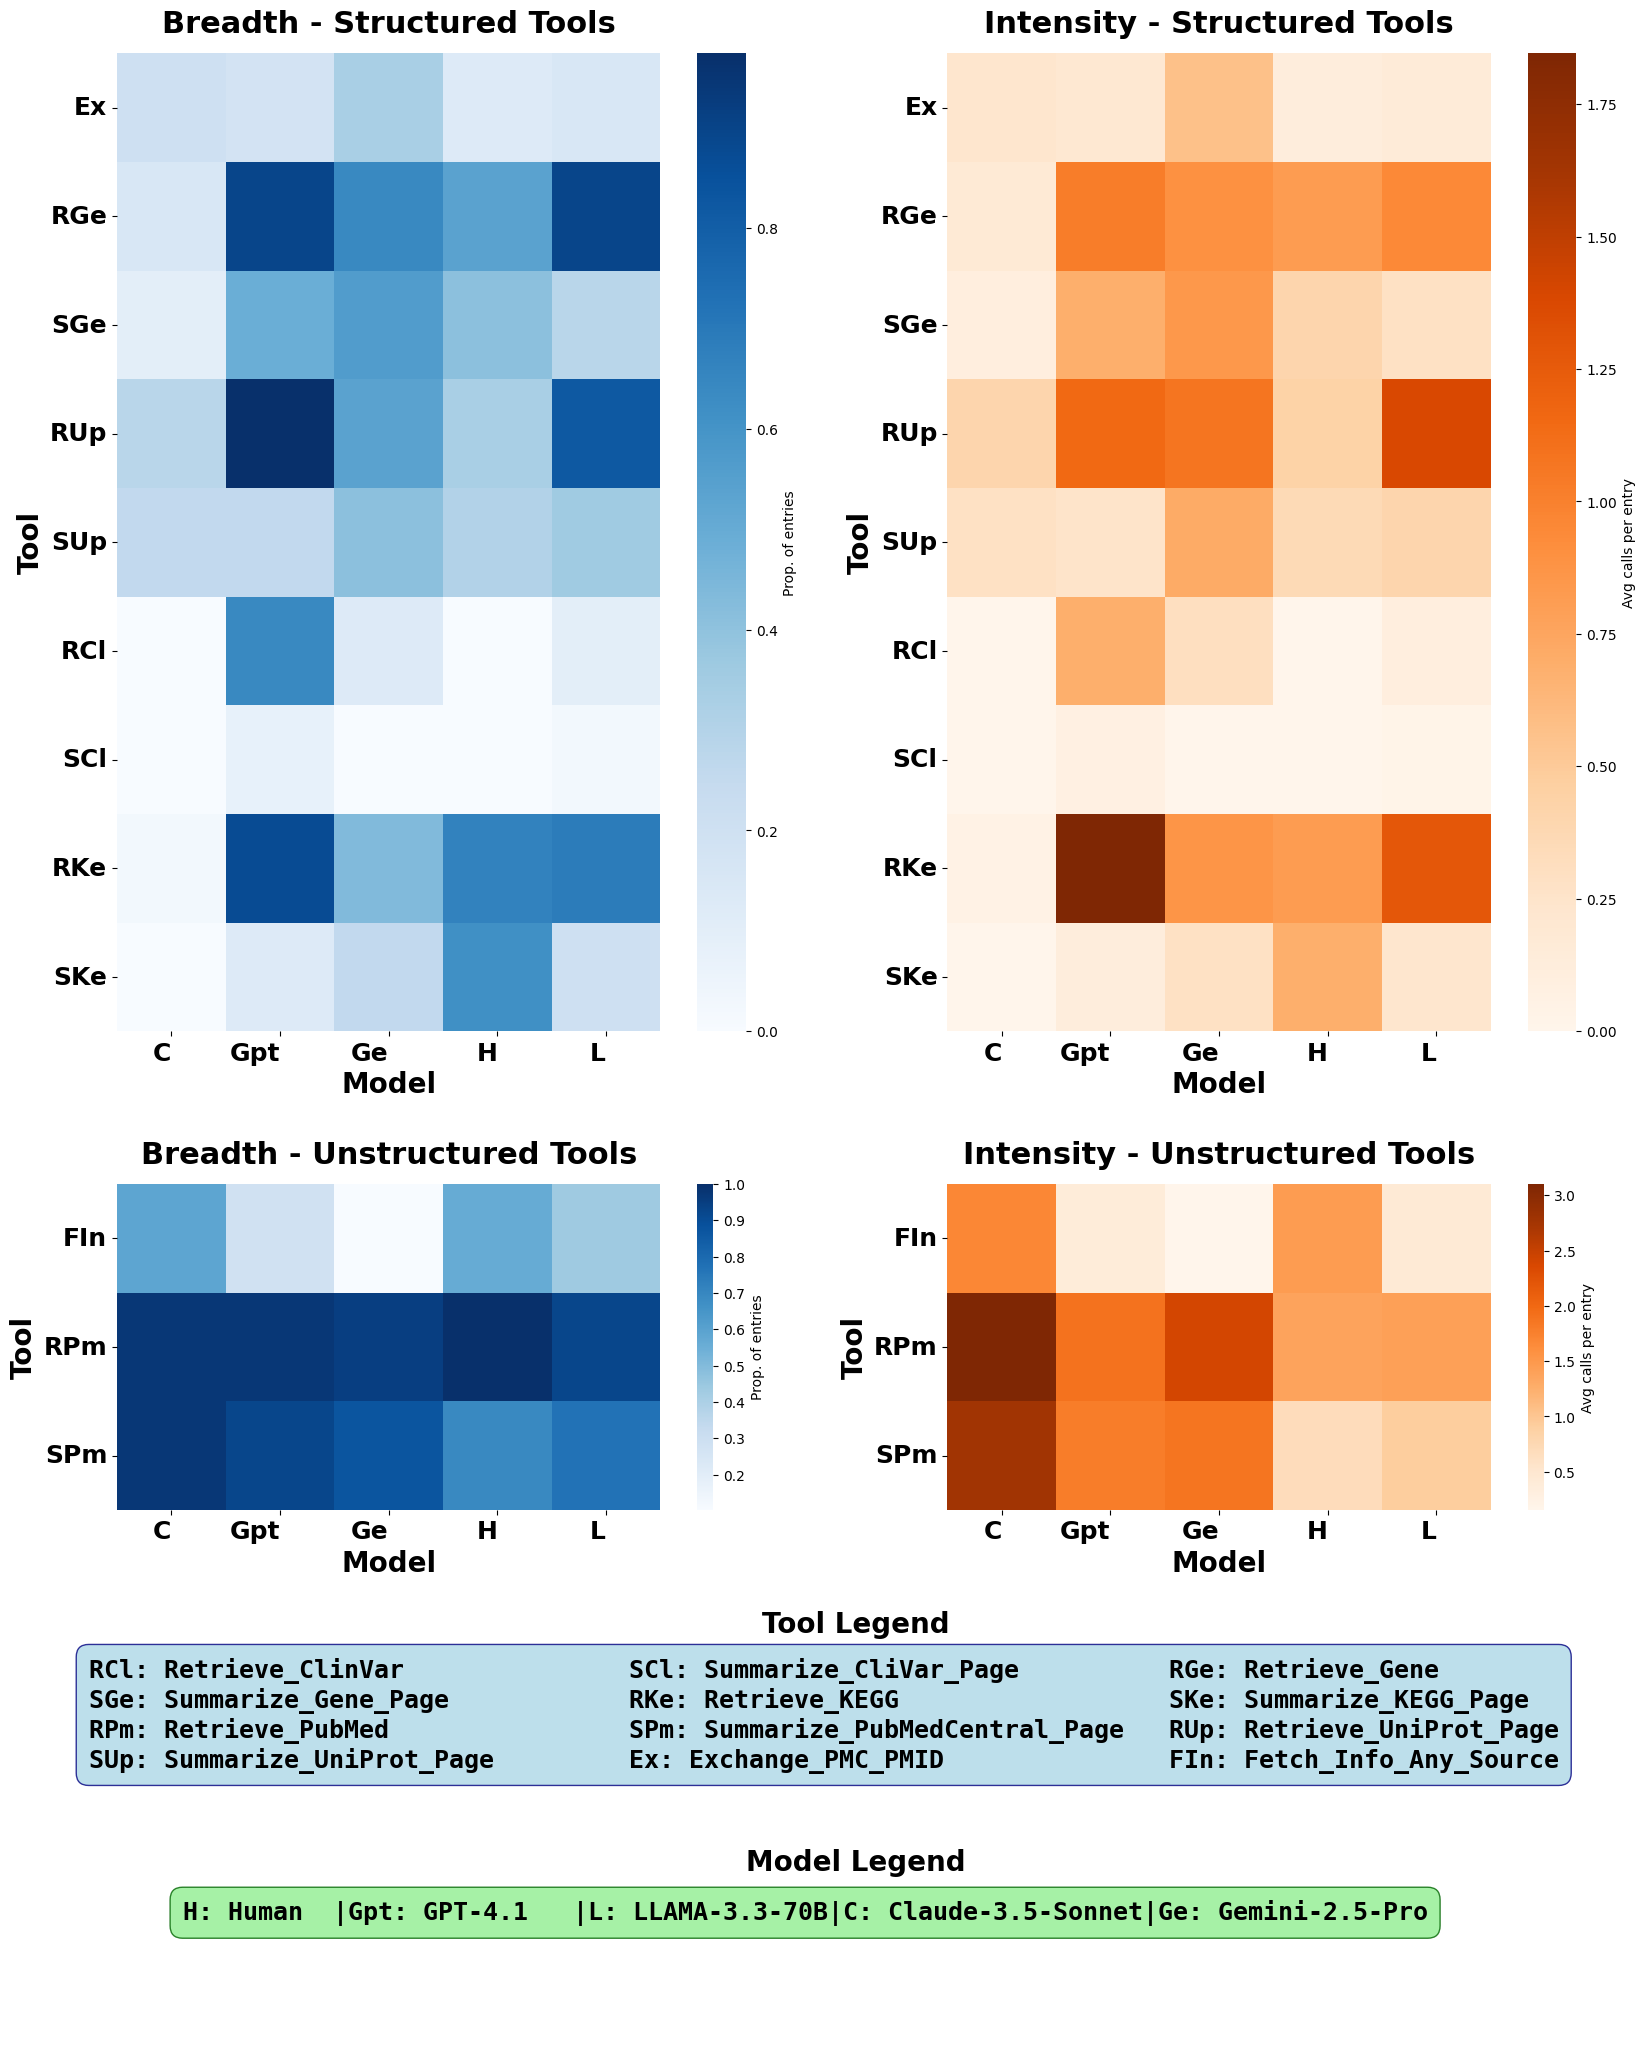


-- Breadth (sample) --
               model                     tool_name  entries_using  \
0  Claude-3.5-Sonnet              Retrieve_ClinVar              0   
1  Claude-3.5-Sonnet         Summarize_CliVar_Page              0   
2  Claude-3.5-Sonnet                 Retrieve_Gene              6   
3  Claude-3.5-Sonnet           Summarize_Gene_Page              4   
4  Claude-3.5-Sonnet                 Retrieve_KEGG              1   
5  Claude-3.5-Sonnet           Summarize_KEGG_Page              0   
6  Claude-3.5-Sonnet               Retrieve_PubMed             38   
7  Claude-3.5-Sonnet  Summarize_PubMedCentral_Page             38   
8  Claude-3.5-Sonnet         Retrieve_UniProt_Page             11   
9  Claude-3.5-Sonnet        Summarize_UniProt_Page             10   

   total_entries  usage_proportion  
0             39          0.000000  
1             39          0.000000  
2             39          0.153846  
3             39          0.102564  
4             39          0.025

In [108]:


# ---------------------------
# NORMALIZE: ensure every (model, entry_id) pair exists; missing => tools_used = []
all_models = tool_df_raw["model"].unique()
all_entry_ids = tool_df_raw["entry_id"].unique()
full_index = pd.MultiIndex.from_product(
    [all_entry_ids, all_models],
    names=["entry_id", "model"]
)
# Reindex to full grid
tool_df = (
    tool_df_raw
    .set_index(["entry_id", "model"])
    .reindex(full_index, fill_value=None)
    .reset_index()
)
# Replace None tools_used with empty list
tool_df["tools_used"] = tool_df["tools_used"].apply(lambda x: x if isinstance(x, list) else [])

# ---------------------------
# Precompute per-row Counter and total calls
tool_df["tool_counter"] = tool_df["tools_used"].apply(Counter)
tool_df["total_calls"] = tool_df["tools_used"].apply(len)

# ---------------------------
# 1. Breadth: proportion of entries per model that use each tool at least once
entries_per_model = (
    tool_df
    .groupby("model")["entry_id"]
    .nunique()
    .rename("total_entries")
    .reset_index()
)

breadth_records = []
for model, sub in tool_df.groupby("model"):
    total = entries_per_model.loc[entries_per_model["model"] == model, "total_entries"].iloc[0]
    for tool in FULL_TOOL_LIST:
        # Count distinct entry_ids where this tool appears ≥1
        has_tool = sub[sub["tool_counter"].apply(lambda c, t=tool: c.get(t, 0) > 0)]
        entries_using = has_tool["entry_id"].nunique()
        breadth_records.append({
            "model": model,
            "tool_name": tool,
            "entries_using": entries_using,
            "total_entries": total,
            "usage_proportion": entries_using / total if total > 0 else 0.0
        })

breadth = pd.DataFrame(breadth_records)
breadth_pivot = (
    breadth
    .pivot(index="model", columns="tool_name", values="usage_proportion")
    .reindex(index=sorted(breadth["model"].unique()), columns=FULL_TOOL_LIST, fill_value=0)
)

# ---------------------------
# 2. Intensity: average call count per entry (could be >1)
intensity_records = []
for model, sub in tool_df.groupby("model"):
    for tool in FULL_TOOL_LIST:
        counts_per_entry = sub["tool_counter"].apply(lambda c, t=tool: c.get(t, 0))
        avg_calls = counts_per_entry.mean()
        intensity_records.append({
            "model": model,
            "tool_name": tool,
            "avg_calls_per_entry": avg_calls
        })

avg_intensity = pd.DataFrame(intensity_records)
intensity_pivot = (
    avg_intensity
    .pivot(index="model", columns="tool_name", values="avg_calls_per_entry")
    .reindex(index=sorted(avg_intensity["model"].unique()), columns=FULL_TOOL_LIST, fill_value=0)
)

# ---------------------------
# 3. Tool entropy per entry (diversity): Shannon entropy over tool-call distribution per (model, entry)
def compute_entropy_from_counter(counter_obj):
    counts = np.array(list(counter_obj.values()), dtype=float)
    if counts.sum() == 0:
        return 0.0
    probs = counts / counts.sum()
    return entropy(probs, base=2)  # bits

entropy_df = tool_df.copy()
entropy_df["tool_entropy"] = entropy_df["tool_counter"].apply(compute_entropy_from_counter)

# Average entropy per model
entropy_summary = (
    entropy_df
    .groupby("model")["tool_entropy"]
    .mean()
    .reset_index()
)

# ---------------------------
# 4. Combine breadth + entropy to classify behavior
# Number of distinct tools seen per model (presence, disregarding repetitions)
distinct_tools = (
    tool_df
    .explode("tools_used")  # temporary explode for unique count
    .drop_duplicates(subset=["model", "entry_id", "tools_used"])  # presence per entry
    .groupby("model")["tools_used"]
    .nunique()
    .reset_index(name="num_distinct_tools")
)

diversity_summary = entropy_summary.merge(distinct_tools, on="model", how="left")

# Optional heuristic classification
def classify_row(entropy_val, num_tools, max_tools=len(FULL_TOOL_LIST)):
    # Simple thresholds; tweak as needed
    if entropy_val >= 1.5 and num_tools >= (0.5 * max_tools):
        return "Swiss Army Knife"
    if entropy_val < 1.0 and num_tools <= 2:
        return "Single Hammer"
    return "Mixed"

diversity_summary["behavior_type"] = diversity_summary.apply(
    lambda r: classify_row(r["tool_entropy"], r["num_distinct_tools"], max_tools=len(FULL_TOOL_LIST)),
    axis=1
)

# ---------------------------
# Create mappings for short labels
def create_short_label_dataframe(pivot_df, full_to_short_map):
    """Convert full tool names to short labels and reorder columns"""
    # Create mapping from full tool names to short labels
    pivot_df_short = pivot_df.rename(columns=full_to_short_map)
    
    # Reorder columns according to X_AXIS_ORDER, only including available columns
    available_cols = [col for col in X_AXIS_ORDER if col in pivot_df_short.columns]
    if available_cols:  # Only select if we have matching columns
        pivot_df_short = pivot_df_short[available_cols]
    
    return pivot_df_short

# Create mapping from full names to short labels
full_to_short_map = dict(zip(FULL_TOOL_LIST, SHORT_LABELS))

# Convert pivot tables to use short labels
breadth_pivot_short = create_short_label_dataframe(breadth_pivot, full_to_short_map)
intensity_pivot_short = create_short_label_dataframe(intensity_pivot, full_to_short_map)

# ---------------------------
# 5. Enhanced Visualization with Tool Groups and Model Legend

# Common font size variable for easy adjustment
FONT_SIZES = {
    'title': 22,
    'axis_label': 20,
    'tick_label': 18,
    'legend': 20
}

def get_model_abbreviations(data_pivot):
    """Convert model names to abbreviations for axis labels"""
    model_names = data_pivot.index.tolist()
    abbreviated_names = [MODEL_LEGEND.get(model, model) for model in model_names]
    return abbreviated_names

def create_tool_legend_text():
    """Create formatted tool legend with 3 columns, 4 rows, left aligned"""
    items = []
    for short, full in TOOL_LEGEND.items():
        if short in X_AXIS_ORDER:  # Only show tools that are displayed
            items.append(f"{short}: {full}")
    
    # Pad items to ensure we have exactly 12 items (3 columns × 4 rows)
    while len(items) < 12:
        items.append("")
    
    # Create 4 rows with 3 columns each
    lines = []
    for row in range(4):
        line_items = []
        for col in range(3):
            idx = row * 3 + col
            if idx < len(items):
                line_items.append(items[idx])
            else:
                line_items.append("")
        
        # Format with fixed width for each column (left aligned)
        formatted_line = f"{line_items[0]:<35} {line_items[1]:<35} {line_items[2]:<35}"
        lines.append(formatted_line.rstrip())
    
    return "\n".join(lines)

def create_model_legend_text():
    """Create formatted model legend with 3 columns, left aligned"""
    items = []
    for full_model, abbrev in MODEL_LEGEND.items():
        if full_model in breadth_pivot_short.index:  # Only show models that exist in data
            items.append(f"{abbrev}: {full_model}")
    
    lines = []
    for i in range(0, len(items), 5):
        line_items = items[i:i+5]
        # Format with fixed width for each column (left aligned)
        formatted_line = f"{line_items[0]:<10}|{line_items[1]:<15}|{line_items[2]:<15}|{line_items[3]:<15}|{line_items[4]:<15}"
        lines.append(formatted_line.rstrip())
    
    return "\n".join(lines)

def create_3x2_visualization(breadth_data, intensity_data, tool_groups):
    """Create 3x2 grid: Row 1: Group1 Breadth, Group1 Intensity
                        Row 2: Group2 Breadth, Group2 Intensity
                        Row 3: Combined Legends spanning both columns"""
    
    # Get tool groups (assume we have exactly 2 groups)
    group_names = list(tool_groups.keys())
    if len(group_names) < 2:
        print("Warning: Need at least 2 tool groups for this layout")
        return
    
    # Calculate available tools for each group
    group1_tools = tool_groups[group_names[0]]
    group2_tools = tool_groups[group_names[1]]
    available_tools_g1 = [tool for tool in group1_tools if tool in breadth_data.columns]
    available_tools_g2 = [tool for tool in group2_tools if tool in breadth_data.columns]
    
    # Calculate height ratios based on number of tools to maintain square sizes
    n_tools_g1 = len(available_tools_g1) if available_tools_g1 else 1
    n_tools_g2 = len(available_tools_g2) if available_tools_g2 else 1
    legend_height_ratio = max(n_tools_g1, n_tools_g2) * 0.4  # Slightly increased for better legend spacing
    height_ratios = [n_tools_g1, n_tools_g2, legend_height_ratio]
    
    # Calculate total figure height to maintain square aspect ratio
    n_models = len(breadth_data.index)
    base_width = 18
    square_size = 0.8  # Base size for each square
    total_height = (n_tools_g1 + n_tools_g2) * square_size * (base_width / (2 * n_models)) + 4
    
    # Create figure with custom height ratios (3 rows, 2 columns)
    fig, axes = plt.subplots(3, 2, figsize=(base_width, max(total_height, 10)), 
                            gridspec_kw={'height_ratios': height_ratios})
    
    # Get model abbreviations
    model_abbrevs = get_model_abbreviations(breadth_data)
    
    # Row 1: Tool Group 1
    group1_name = group_names[0]
    
    # Group 1 Breadth (Row 1, Col 1)
    if available_tools_g1:
        g1_breadth_data = breadth_data[available_tools_g1].T
        
        sns.heatmap(g1_breadth_data, annot=False, cmap="Blues", square=True,
                   cbar_kws={"label": "Prop. of entries"}, ax=axes[0, 0])
        axes[0, 0].set_title(f"Breadth - {group1_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
        axes[0, 0].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[0, 0].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[0, 0].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
        axes[0, 0].set_yticklabels(axes[0, 0].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
    # Group 1 Intensity (Row 1, Col 2)
    if available_tools_g1:
        g1_intensity_data = intensity_data[available_tools_g1].T
        
        sns.heatmap(g1_intensity_data, annot=False, cmap="Oranges", square=True,
                   cbar_kws={"label": "Avg calls per entry"}, ax=axes[0, 1])
        axes[0, 1].set_title(f"Intensity - {group1_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
        axes[0, 1].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[0, 1].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[0, 1].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
        axes[0, 1].set_yticklabels(axes[0, 1].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
    # Row 2: Tool Group 2
    group2_name = group_names[1]
    
    # Group 2 Breadth (Row 2, Col 1)
    if available_tools_g2:
        g2_breadth_data = breadth_data[available_tools_g2].T
        
        sns.heatmap(g2_breadth_data, annot=False, cmap="Blues", square=True,
                   cbar_kws={"label": "Prop. of entries"}, ax=axes[1, 0])
        axes[1, 0].set_title(f"Breadth - {group2_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
        axes[1, 0].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[1, 0].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[1, 0].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
        axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
    # Group 2 Intensity (Row 2, Col 2)
    if available_tools_g2:
        g2_intensity_data = intensity_data[available_tools_g2].T
        
        sns.heatmap(g2_intensity_data, annot=False, cmap="Oranges", square=True,
                   cbar_kws={"label": "Avg calls per entry"}, ax=axes[1, 1])
        axes[1, 1].set_title(f"Intensity - {group2_name}", fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
        axes[1, 1].set_xlabel("Model", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[1, 1].set_ylabel("Tool", fontsize=FONT_SIZES['axis_label'], fontweight='bold')
        axes[1, 1].set_xticklabels(model_abbrevs, rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
        axes[1, 1].set_yticklabels(axes[1, 1].get_yticklabels(), rotation=0, ha="right", fontsize=FONT_SIZES['tick_label'], fontweight='bold')
    
    # Row 3: Combined Legends spanning both columns with boxes
    # Remove the subplot divisions for the legend row and create a single axis
    axes[2, 0].remove()
    axes[2, 1].remove()
    
    # Create a single subplot spanning both columns for legends
    legend_ax = fig.add_subplot(3, 1, 3)
    legend_ax.axis('off')
    
    # Create separate legend texts
    tool_legend = create_tool_legend_text()
    model_legend = create_model_legend_text()
    
    # Display Tool Legend with box (upper part)
    # tool_legend_formatted = f"Tool Legend:\n{tool_legend}"
    legend_ax.text(0.5, 0.76, "Tool Legend", transform=legend_ax.transAxes, 
                fontsize=FONT_SIZES['legend'], verticalalignment='center', 
                horizontalalignment='center', fontweight='bold')
    
    legend_ax.text(0.01, 0.60, tool_legend, transform=legend_ax.transAxes, 
                   fontsize=FONT_SIZES['legend']-2, verticalalignment='center', 
                   horizontalalignment='left', fontweight='bold', family='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8, edgecolor="navy"))
    
    legend_ax.text(0.5, 0.34, "Model Legend", transform=legend_ax.transAxes, 
            fontsize=FONT_SIZES['legend'], verticalalignment='center', 
            horizontalalignment='center', fontweight='bold')
    
    # Display Model Legend with box (lower part)
    # model_legend_formatted = f"Model Legend:\n{model_legend}"
    legend_ax.text(0.07, 0.25, model_legend, transform=legend_ax.transAxes, 
                   fontsize=FONT_SIZES['legend']-2, verticalalignment='center', 
                   horizontalalignment='left', fontweight='bold', family='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.8, edgecolor="darkgreen"))
    
    plt.tight_layout(pad=3.0)
    return fig

# Check if we have data before plotting
if (not breadth_pivot_short.empty and breadth_pivot_short.shape[1] > 0 and
    not intensity_pivot_short.empty and intensity_pivot_short.shape[1] > 0):
    
    # Create 3x2 visualization with legends at the bottom
    fig_combined = create_3x2_visualization(breadth_pivot_short, intensity_pivot_short, TOOL_GROUPS)
    filename = "Heatmaps_for_tool_usage"
    os.makedirs(images_folder, exist_ok=True)
    plt.savefig(os.path.join(images_folder, filename), dpi=300, bbox_inches="tight")
        
    plt.show()
else:
    print("Warning: Missing data for combined visualization")

# ---------------------------
# 6. Output summaries
print("\n-- Breadth (sample) --")
print(breadth.head(10))

print("\n-- Intensity (sample) --")
print(avg_intensity.head(10))

print("\n-- Entropy summary --")
print(entropy_summary)

print("\n-- Diversity summary with classification --")
print(diversity_summary)

print("\n-- Tool Groups --")
for group_name, tools in TOOL_GROUPS.items():
    print(f"{group_name}: {', '.join(tools)}")

print("\n-- Tool Legend --")
for short, full in TOOL_LEGEND.items():
    print(f"{short}: {full}")

print("\n-- Model Legend --")
for full, abbrev in MODEL_LEGEND.items():
    print(f"{abbrev}: {full}")

In [110]:
entropy_summary.T.to_csv(f"{images_folder}/entropy.csv")
avg_intensity.to_csv(f"{images_folder}/avg_intensity.csv")
breadth.to_csv(f"{images_folder}/breadth.csv")
diversity_summary.to_csv(f"{images_folder}/diversity_summary.csv")

# Cohen-kappa score for LLM-Judgement and Human Scores

In [162]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# ---------------------------
# Assumed input DataFrame:
# Columns: 'model', 'output_id', 'criterion', 'llm_score', 'human_score'
# Likert-scale integers (e.g., 1..5) for both scores.
# Replace this with your actual data.
df = pd.DataFrame([
    # model M1, two outputs, two criteria for illustration; extend to all 6 criteria and real data
    {"model": "M1", "output_id": 1, "criterion": "readability",    "llm_score": 4, "human_score": 5},
    {"model": "M1", "output_id": 1, "criterion": "thoroughness",  "llm_score": 3, "human_score": 3},
    {"model": "M2", "output_id": 2, "criterion": "readability",    "llm_score": 2, "human_score": 2},
    {"model": "M2", "output_id": 2, "criterion": "thoroughness",  "llm_score": 5, "human_score": 4},
    # add other models and criteria...
])

# ---------------------------
def compute_quadratic_kappa(human, llm):
    return cohen_kappa_score(human, llm, weights="quadratic")

def bootstrap_kappa(human, llm, n_boot=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(human)
    if n < 2:
        return np.nan, np.nan, np.nan
    bootstrapped = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        h_sample = human[idx]
        l_sample = llm[idx]
        bootstrapped.append(cohen_kappa_score(h_sample, l_sample, weights="quadratic"))
    bootstrapped = np.array(bootstrapped)
    point = cohen_kappa_score(human, llm, weights="quadratic")
    lower = np.nanpercentile(bootstrapped, 2.5)
    upper = np.nanpercentile(bootstrapped, 97.5)
    return point, lower, upper

# ---------------------------
# 1. Aggregate per model (pooling all criteria)
model_records = []
for model, sub in df.groupby("model"):
    human = sub["human_score"].to_numpy()
    llm = sub["llm_score"].to_numpy()
    kappa, lo, hi = bootstrap_kappa(human, llm, n_boot=1000, random_state=42)
    model_records.append({
        "model": model,
        "kappa_quadratic_pooled": kappa,
        "ci_lower_95": lo,
        "ci_upper_95": hi,
        "n_pairs": len(human),
    })
model_aggregate_df = pd.DataFrame.from_records(model_records).sort_values("model")

# ---------------------------
# 2. Per-criterion kappas per model (for comparison / secondary aggregate)
per_criterion = []
for (model, criterion), sub in df.groupby(["model", "criterion"]):
    human = sub["human_score"].to_numpy()
    llm = sub["llm_score"].to_numpy()
    kappa = compute_quadratic_kappa(human, llm)
    per_criterion.append({
        "model": model,
        "criterion": criterion,
        "kappa_quadratic": kappa,
        "n_pairs": len(human),
    })
per_criterion_df = pd.DataFrame.from_records(per_criterion)

# Optional: average of per-criterion kappas per model (simple mean)
avg_per_criterion = (
    per_criterion_df
    .groupby("model")["kappa_quadratic"]
    .mean()
    .reset_index(name="mean_per_criterion_kappa")
)

# ---------------------------
# 3. Final combined table
final = (
    model_aggregate_df
    .merge(avg_per_criterion, on="model", how="left")
    .rename(columns={
        "kappa_quadratic_pooled": "kappa_pooled_quadratic",
    })
)

# Display
print("Aggregate agreement per model (pooled across all criteria):")
print(final[[
    "model",
    "kappa_pooled_quadratic",
    "ci_lower_95",
    "ci_upper_95",
    "mean_per_criterion_kappa",
    "n_pairs"
]])


Aggregate agreement per model (pooled across all criteria):
  model  kappa_pooled_quadratic  ci_lower_95  ci_upper_95  \
0    M1             0.666667             0.0     0.666667   
1    M2             0.666667             0.0     0.666667   

   mean_per_criterion_kappa  n_pairs  
0                  0.0             2  
1                  0.0             2  


In [6]:
def remove_observations_human(thought_process):
   keys_to_remove = {'observation', 'table'}
   thoughts_n_actions = [
       {k: v for k, v in d.items() if k not in keys_to_remove}
       for d in thought_process
   ]
   return thoughts_n_actions

few_shot_library = []
for index, row in final_df.iterrows():
   if row['id'] in [3, 6, 11, 14, 17, 24, 50, 52, 54, 56, 57, 59]:
       tp = row["parsed_thoughtprocess"]
       if tp != None:
           few_shot_library.append({"example":row['id'], "Question":row['question'], "Thought Process:":remove_observations_human(tp)})

In [7]:
few_shot_library

[{'example': 3,
  'Question': 'What are synovial fibroblasts (FLS)?',
  'Thought Process:': [{'thought': 'I should begin by looking for general information about synovial fibroblasts (FLS) in review papers to understand their fundamental characteristics and functions. PubMed is a suitable source to retrieve relevant scientific papers on this topic.',
    'relevance': '-',
    'action': 'PubMed_Retrieve',
    'action_input': 'synovial fibroblasts AND Review'},
   {'thought': 'I find the two papers highly relevant. Paper with id 18613841 clearly defines synovial fibroblasts and also implication for RA. The other paper with id 34021514 might be good to use the summary function on since, it is going into detail of synovial fibroblasts function and development. As the PMCIDs for the two papers arent available, I will try to figure out the related pathways from the KEGG database.',
    'relevance': '18613841, 34021514',
    'action': 'KEGG_Retrieve',
    'action_input': 'synovial fibroblast'

In [33]:
a=pd.read_csv("/Users/charvijain16/PhD/PaperDataset/failure_rates/my_dataset_direct_gpt_oss_failure_rates.csv")

In [34]:
a.columns

Index(['Unnamed: 0', 'id', 'thoughts_n_actions', 'model_type', 'redirections',
       'self_monitoring_checks', 'forgetting_incidents', 'invalid_tool_calls',
       'repeated_tool_calls_due_to_bad_input'],
      dtype='object')

In [38]:
import pandas as pd
import glob
import os

# Path to your folder (use "." if running from the same directory)
DATA_DIR = "/Users/charvijain16/PhD/PaperDataset/failure_rates"

all_dfs = []

for file_path in glob.glob(os.path.join(DATA_DIR, "*.csv")):
    filename = os.path.basename(file_path)

    # Read CSV
    df = pd.read_csv(file_path)

    # Add dataset column
    df["dataset"] = "my_dataset"

    # Infer type
    if "direct" in filename:
        df["type"] = "direct"
    elif "DPP" in filename:
        df["type"] = "DPP"
    elif "few_shot" in filename:
        df["type"] = "few_shot"
    else:
        df["type"] = "unknown"

    # Infer evaluator
    if "qwen" in filename:
        df["evaluator"] = "qwen"
    elif "gpt_oss" in filename:
        df["evaluator"] = "gpt_oss"
    else:
        df["evaluator"] = "unknown"

    all_dfs.append(df)

# Concatenate everything
final_df = pd.concat(all_dfs, ignore_index=True)

# Save combined CSV
final_df.to_csv(f"{DATA_DIR}/my_dataset_all_failure_rates.csv", index=False)

print("Saved combined file as my_dataset_all_failure_rates.csv")


Saved combined file as my_dataset_all_failure_rates.csv


In [35]:
b=pd.read_csv("/Users/charvijain16/PhD/PaperDataset/Dataset_paper_DEC_2025/all_model_outputs_CSV_cleaned/my_dataset/direct/claude-3-5-sonnet-20240620_results.csv")

In [36]:
b.columns

Index(['id', 'Name', 'category', 'question', 'wtp_completion_tokens',
       'wtp_total_tokens', 'total_intermediate_steps', 'unique_tool_count',
       'original_TP_completion_tokens', 'original_TP_total_tokens',
       'formatted_TP_tokens', 'clean_TP_tokens',
       'drop_tokens_after_preprocessing', 'wtnp_completion_tokens',
       'wtnp_total_tokens', 'wot_completion_tokens', 'wot_total_tokens',
       'error'],
      dtype='object')

In [51]:
import pandas as pd
from pathlib import Path

# Root dataset directory
root_dir = Path("/Users/charvijain16/PhD/PaperDataset/Dataset_paper_DEC_2025/all_model_outputs_CSV_cleaned/my_dataset")

# Map folder → configuration
config_map = {
    "direct": "direct",
    "DPP_corrected_few_shot_3": "DPP",
    "few_shot": "few_shot"
}

# Function to infer model name from filename
def get_model_name(filename):
    fname = filename.lower()
    if "llama" in fname:
        return "llama"
    if "gpt" in fname:
        return "gpt"
    if "claude" in fname:
        return "claude"
    if "gemini" in fname:
        return "gemini"
    return "unknown"

all_rows = []

for folder in root_dir.iterdir():
    if not folder.is_dir():
        continue

    configuration = config_map.get(folder.name)
    if configuration is None:
        continue

    for csv_file in folder.glob("*.csv"):
        df = pd.read_csv(csv_file)

        # Keep only required columns
        df = df[["id", "total_intermediate_steps"]].copy()

        # Add metadata columns
        df["configuration"] = configuration
        df["model name"] = get_model_name(csv_file.name)

        all_rows.append(df)

# Combine everything
final_df = pd.concat(all_rows, ignore_index=True)

# Save result
final_df.to_csv(f"{root_dir}/all_combined_total_intermediate_steps.csv", index=False)

# print("Saved combined_results.csv")


In [62]:
df1 = pd.read_csv(f"{DATA_DIR}/my_dataset_all_failure_rates.csv")
df2 = pd.read_csv(f"{root_dir}/all_combined_total_intermediate_steps.csv")


In [63]:
df1.shape, df2.shape

((1650, 12), (696, 4))

In [64]:
df2.columns

Index(['id', 'total_intermediate_steps', 'configuration', 'model name'], dtype='object')

In [65]:
df1.head()

,Unnamed: 0,id,thoughts_n_actions,model_type,redirections,self_monitoring_checks,forgetting_incidents,invalid_tool_calls,repeated_tool_calls_due_to_bad_input,dataset,type,evaluator
0,0,1,[{'Thought': 'Thought: I should begin by looki...,llama,4.0,2.0,0.0,0.0,1.0,my_dataset,DPP,qwen
1,1,2,"[{'Thought': ""Thought: First, let's identify t...",llama,0.0,0.0,0.0,0.0,0.0,my_dataset,DPP,qwen
2,2,4,[{'Thought': 'Thought: I should begin by looki...,llama,0.0,0.0,0.0,0.0,0.0,my_dataset,DPP,qwen
3,3,5,[{'Thought': 'Thought: I will start by searchi...,llama,1.0,0.0,0.0,0.0,0.0,my_dataset,DPP,qwen
4,4,7,[{'Thought': 'Thought: To understand the role ...,llama,2.0,0.0,0.0,0.0,0.0,my_dataset,DPP,qwen


In [66]:
df1_qwen = df1[df1["evaluator"] == "qwen"]
df_gpt_oss = df1[df1["evaluator"] == "gpt_oss"]

In [67]:
df1_qwen.shape, df_gpt_oss.shape

((825, 12), (825, 12))

In [70]:
825-129

696

In [71]:
import pandas as pd

df1 = pd.read_csv(f"{DATA_DIR}/my_dataset_all_failure_rates.csv")
df2 = pd.read_csv(f"{root_dir}/all_combined_total_intermediate_steps.csv")

merged_qwen = df1_qwen.merge(
    df2,
    left_on=["id", "type","model_type"],
    right_on=["id", "configuration","model name"],
    how="left"   # change if needed
)



In [72]:
merged_qwen.shape

(825, 15)

In [73]:
merged_gpt_oss = df_gpt_oss.merge(
    df2,
    left_on=["id", "type","model_type"],
    right_on=["id", "configuration","model name"],
    how="left"   # change if needed
)



In [74]:
merged_qwen.to_csv(f"{DATA_DIR}/my_dataset_qwen_all_failure_rates.csv", index=False)
merged_gpt_oss.to_csv(f"{DATA_DIR}/my_dataset_gpt_oss_all_failure_rates.csv", index=False)

In [75]:
df = pd.read_csv(f"{DATA_DIR}/my_dataset_all_failure_rates_normalized.csv")

In [76]:
df.shape

(1650, 17)

In [77]:
df.columns

Index(['id', 'thoughts_n_actions', 'model_type', 'redirections',
       'self_monitoring_checks', 'forgetting_incidents', 'invalid_tool_calls',
       'repeated_tool_calls_due_to_bad_input', 'dataset', 'type', 'evaluator',
       'total_intermediate_steps', 'Avg_redirections', 'Avg_Self_monitoring',
       'Avg_forgetting', 'Avg_invalid_tool_calls', 'Avg_Repeated_tool_calls'],
      dtype='object')

In [84]:
df.head()

,id,thoughts_n_actions,model_type,redirections,self_monitoring_checks,forgetting_incidents,invalid_tool_calls,repeated_tool_calls_due_to_bad_input,dataset,type,evaluator,total_intermediate_steps,Avg_redirections,Avg_Self_monitoring,Avg_forgetting,Avg_invalid_tool_calls,Avg_Repeated_tool_calls
0,1,[{'Thought': 'Thought: I should begin by looki...,llama,5.0,5.0,0.0,0.0,1.0,my_dataset,DPP,gpt_oss,10.0,0.5,0.5,0,0,0.1
1,2,"[{'Thought': ""Thought: First, let's identify t...",llama,0.0,0.0,0.0,0.0,0.0,my_dataset,DPP,gpt_oss,4.0,0,0,0,0,0
2,4,[{'Thought': 'Thought: I should begin by looki...,llama,0.0,0.0,0.0,0.0,0.0,my_dataset,DPP,gpt_oss,2.0,0,0,0,0,0
3,5,[{'Thought': 'Thought: I will start by searchi...,llama,1.0,1.0,0.0,0.0,0.0,my_dataset,DPP,gpt_oss,4.0,0.25,0.25,0,0,0
4,7,[{'Thought': 'Thought: To understand the role ...,llama,2.0,0.0,0.0,0.0,0.0,my_dataset,DPP,gpt_oss,6.0,0.333333333,0,0,0,0


In [81]:
a=df['thoughts_n_actions'][0]

In [85]:
df_human = df[df["model_type"] == "Human"]

In [ ]:
df_all = df[df["model_type"] != "Human"]

In [89]:
df_all.shape

(1392, 17)

In [86]:
df_human.shape

(258, 17)

In [87]:
import pandas as pd
import ast

def count_dicts_from_string(x):
    try:
        parsed = ast.literal_eval(x)
        return (len(parsed) - 1)
    except (ValueError, SyntaxError, TypeError):
        return 0   # or None / np.nan depending on your preference

df_human["num_dicts"] = df_human["thoughts_n_actions"].apply(count_dicts_from_string)

In [91]:
combined_df = pd.concat([df_human, df_all], ignore_index=True)

In [92]:
combined_df.to_csv(f"{DATA_DIR}/my_dataset_all_failure_rates_normalized_with_humans.csv")

In [82]:
import ast 

# Convert string to Python object
parsed = ast.literal_eval(a)

# Count dictionaries in the list
num_dicts = len(parsed)

In [ ]:
num_dicts-1

11